# Electricity Demand Forecasting Dataset

## Data Sources

The dataset is collected from multiple reliable sources:

-  **Power Grid Company of Bangladesh (PGCB)**  
-  **Weather Data Sources**  
---

##  Data Integration

All datasets are merged using the `datetime column`.

This allows us to:
- Align power and weather data accurately  
- Perform time-based analysis  
- Understand real-world patterns in electricity usage  

---

##  Objectives

### 1.  Forecast Electricity Demand
- Predict future `demand_mw` values  
- Help in planning electricity supply  

### 2.  Estimate Actual Demand
- Include `load shedding` to estimate real demand  
- Understand hidden or unmet demand  

### 3.  Analyze Key Impacts
---
### Steps:
- Understanding Dataset
- Data Preprocessing
- EDA & Advance Data Processing
- Model Evaluation

In [1]:
# import dependencies
import pandas as pd
import numpy as np

# Dataset Loading

In [2]:
# dataset load
df = pd.read_csv("electricity_demand_weather_merged.csv")

In [3]:
df.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,temperature,humidity,rain,windspeed
0,2020-01-01 00:00:00,5913.0,5913,0,5493,0,160,47,0.0,NaN,129,76,NaN,NaN,NaN,18.3,74.0,0.0,3.5
1,2020-01-01 01:00:00,5570.0,5570,0,5117,0,160,47,0.0,NaN,129,74,NaN,NaN,NaN,16.5,81.0,0.0,6.0
2,2020-01-01 02:00:00,5351.0,5351,0,4900,0,159,47,0.0,NaN,129,72,NaN,NaN,NaN,14.6,89.0,0.0,8.4
3,2020-01-01 03:00:00,5223.0,5223,0,4773,0,160,46,0.0,NaN,129,70,NaN,NaN,NaN,14.5,90.0,0.0,6.3
4,2020-01-01 04:00:00,5142.0,5142,0,4697,0,159,46,0.0,NaN,129,68,NaN,NaN,NaN,14.1,90.0,0.0,8.2


In [4]:
df.tail()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,temperature,humidity,rain,windspeed
49847,2025-06-16 20:00:00,15000.0,15035,33,6361,1985,4168,172,0.0,64.0,924,26,1262.0,38.0,NaN,27.6,89.0,0.0,14.3
49848,2025-06-16 21:00:00,14971.0,15000,28,6373,1961,4134,172,0.0,59.0,924,40,1270.0,38.0,NaN,27.2,89.0,0.0,15.2
49849,2025-06-16 22:00:00,15109.0,15130,20,6421,1955,4228,172,0.0,45.0,924,36,1290.0,38.0,NaN,27.0,90.0,0.0,14.2
49850,2025-06-16 23:00:00,15165.0,15205,38,6437,1984,4268,172,0.0,41.0,924,42,1259.0,38.0,NaN,26.8,91.0,0.0,13.7
49851,2025-06-17 00:00:00,14628.0,14650,21,6302,1672,4186,172,0.0,41.0,924,42,1251.0,38.0,NaN,26.7,91.0,0.1,14.3


In [5]:
df.columns

Index(['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas',
       'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_tripura', 'india_adani', 'nepal', 'remarks', 'temperature',
       'humidity', 'rain', 'windspeed'],
      dtype='object')

In [6]:
df.dtypes

datetime                 object
generation_mw           float64
demand_mw                 int64
load_shedding             int64
gas                       int64
liquid_fuel               int64
coal                      int64
hydro                     int64
solar                   float64
wind                    float64
india_bheramara_hvdc      int64
india_tripura             int64
india_adani             float64
nepal                   float64
remarks                  object
temperature             float64
humidity                float64
rain                    float64
windspeed               float64
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49852 entries, 0 to 49851
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              49852 non-null  object 
 1   generation_mw         49852 non-null  float64
 2   demand_mw             49852 non-null  int64  
 3   load_shedding         49852 non-null  int64  
 4   gas                   49852 non-null  int64  
 5   liquid_fuel           49852 non-null  int64  
 6   coal                  49852 non-null  int64  
 7   hydro                 49852 non-null  int64  
 8   solar                 49852 non-null  float64
 9   wind                  18664 non-null  float64
 10  india_bheramara_hvdc  49852 non-null  int64  
 11  india_tripura         49852 non-null  int64  
 12  india_adani           7326 non-null   float64
 13  nepal                 5339 non-null   float64
 14  remarks               3794 non-null   object 
 15  temperature        

In [8]:
df.shape

(49852, 19)

# Data Description Table

| Column Name              | Data Type | Description |
|-------------------------|----------|-------------|
| datetime                | object   | Timestamp (needs conversion to datetime) |
| generation_mw           | float64  | Total electricity generation |
| demand_mw               | int64    | supplied (served demand) |
| load_shedding           | int64    | Unserved demand (power shortage) |
| gas                     | int64    | Gas-based generation |
| liquid_fuel             | int64    | Furnace oil / diesel generation |
| coal                    | int64    | Coal-based generation |
| hydro                   | int64    | Hydropower generation |
| solar                   | float64  | Solar generation |
| wind                    | float64  | Wind generation (many missing values) |
| india_bheramara_hvdc    | int64    | Power import via HVDC |
| india_tripura           | int64    | Import from Tripura |
| india_adani             | float64  | Import from Adani (sparse) |
| nepal                   | float64  | Import from Nepal (sparse) |
| remarks                 | object   | Special notes/events |
| temperature             | float64  | Temperature (°C) |
| humidity                | float64  | Humidity (%) |
| rain                    | float64  | Rainfall (mm) |
| windspeed               | float64  | Wind speed |

# Data Preprocessing

In [9]:
# Rename Columns for Consistency
df = df.rename(columns={
    'generation_mw': 'gen_total_mw',
    'load_shedding': 'load_shedding_mw',
    'gas': 'gen_gas_mw',
    'liquid_fuel': 'gen_liquid_fuel_mw',
    'coal': 'gen_coal_mw',
    'hydro': 'gen_hydro_mw',
    'solar': 'gen_solar_mw',
    'wind': 'gen_wind_mw',
    'india_bheramara_hvdc': 'import_india_bheramara_mw',
    'india_tripura': 'import_india_tripura_mw',
    'india_adani': 'import_india_adani_mw',
    'nepal': 'import_nepal_mw',
    'temperature': 'temp_c',
    'humidity': 'humidity_pct',
    'rain': 'rain_mm',
    'windspeed': 'wind_speed_ms'
})

In [10]:
df.head()

,datetime,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,import_india_tripura_mw,import_india_adani_mw,import_nepal_mw,remarks,temp_c,humidity_pct,rain_mm,wind_speed_ms
0,2020-01-01 00:00:00,5913.0,5913,0,5493,0,160,47,0.0,NaN,129,76,NaN,NaN,NaN,18.3,74.0,0.0,3.5
1,2020-01-01 01:00:00,5570.0,5570,0,5117,0,160,47,0.0,NaN,129,74,NaN,NaN,NaN,16.5,81.0,0.0,6.0
2,2020-01-01 02:00:00,5351.0,5351,0,4900,0,159,47,0.0,NaN,129,72,NaN,NaN,NaN,14.6,89.0,0.0,8.4
3,2020-01-01 03:00:00,5223.0,5223,0,4773,0,160,46,0.0,NaN,129,70,NaN,NaN,NaN,14.5,90.0,0.0,6.3
4,2020-01-01 04:00:00,5142.0,5142,0,4697,0,159,46,0.0,NaN,129,68,NaN,NaN,NaN,14.1,90.0,0.0,8.2


In [11]:
# check null value 
df['datetime'].isna().sum()

np.int64(0)

In [12]:
# Convert datetime column
df['datetime'] = pd.to_datetime(df['datetime'])

In [13]:
# Sort values 
df = df.sort_values('datetime')

In [14]:
# Set index
df = df.set_index('datetime')

In [15]:
df.head()

,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,import_india_tripura_mw,import_india_adani_mw,import_nepal_mw,remarks,temp_c,humidity_pct,rain_mm,wind_speed_ms
datetime,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,5913.0,5913,0,5493,0,160,47,0.0,NaN,129,76,NaN,NaN,NaN,18.3,74.0,0.0,3.5
2020-01-01 01:00:00,5570.0,5570,0,5117,0,160,47,0.0,NaN,129,74,NaN,NaN,NaN,16.5,81.0,0.0,6.0
2020-01-01 02:00:00,5351.0,5351,0,4900,0,159,47,0.0,NaN,129,72,NaN,NaN,NaN,14.6,89.0,0.0,8.4
2020-01-01 03:00:00,5223.0,5223,0,4773,0,160,46,0.0,NaN,129,70,NaN,NaN,NaN,14.5,90.0,0.0,6.3
2020-01-01 04:00:00,5142.0,5142,0,4697,0,159,46,0.0,NaN,129,68,NaN,NaN,NaN,14.1,90.0,0.0,8.2


In [16]:
# check missing values
df.isnull().sum()

gen_total_mw                     0
demand_mw                        0
load_shedding_mw                 0
gen_gas_mw                       0
gen_liquid_fuel_mw               0
gen_coal_mw                      0
gen_hydro_mw                     0
gen_solar_mw                     0
gen_wind_mw                  31188
import_india_bheramara_mw        0
import_india_tripura_mw          0
import_india_adani_mw        42526
import_nepal_mw              44513
remarks                      46058
temp_c                        1991
humidity_pct                  1991
rain_mm                       1991
wind_speed_ms                 1991
dtype: int64

In [17]:
# missing values percentage
np.round(df.isna().mean()*100, 2)

gen_total_mw                  0.00
demand_mw                     0.00
load_shedding_mw              0.00
gen_gas_mw                    0.00
gen_liquid_fuel_mw            0.00
gen_coal_mw                   0.00
gen_hydro_mw                  0.00
gen_solar_mw                  0.00
gen_wind_mw                  62.56
import_india_bheramara_mw     0.00
import_india_tripura_mw       0.00
import_india_adani_mw        85.30
import_nepal_mw              89.29
remarks                      92.39
temp_c                        3.99
humidity_pct                  3.99
rain_mm                       3.99
wind_speed_ms                 3.99
dtype: float64

## Null Values in the Dataset

After checking the dataset, I found that **most columns have 0% null values**.

However, the following columns contain **constant non-zero values**, which might indicate placeholder or default data instead of actual collected values:
- `gen_wind_mw` - 62.56% of values are identical
- `import_india_adani_mw` - 85.30% of values are identical
- `import_nepal_mw` - 89.29% of values are identical
- `remarks` – 92.39% of values are identical
- `temp_c` – 3.99% of values are identical
- `humidity_pct` – 3.99% of values are identical
- `rain_mm` – 3.99% of values are identical
- `wind_speed_ms` – 3.99% of values are identical

In [18]:
# Check time range
print("Start:", df.index.min())
print("End:", df.index.max())

Start: 2020-01-01 00:00:00
End: 2025-06-17 00:00:00


## Handling Missing values

### **`gen_wind_mw`,`import_india_adani_mw`, and `import_nepal_mw` columns**
- The missing values in `gen_wind_mw`, `import_india_adani_mw`, and `import_nepal_mw` represent structural zeros rather than true missing data. These sources are inactive for large periods, so missing entries indicate no generation or import. Therefore, filling with zero preserves the real-world meaning of the data and avoids introducing artificial patterns into the model.

In [19]:
# fill missing values
df['gen_wind_mw'].fillna(0, inplace=True)
df['import_india_adani_mw'].fillna(0, inplace=True)
df['import_nepal_mw'].fillna(0, inplace=True)

C:\Users\dclid\AppData\Local\Temp\ipykernel_12208\811341114.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gen_wind_mw'].fillna(0, inplace=True)
C:\Users\dclid\AppData\Local\Temp\ipykernel_12208\811341114.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, whe

### **`remarks` Column**

In [20]:
# find unique remaks value
df['remarks'].unique()

array([nan, 'Day_Peak', 'Evening_Peak'], dtype=object)

In [21]:
# create a new columns of hours (feature engineering)
df['hour'] = df.index.hour

In [22]:
# find unique 'hours'
df['hour'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 23, 22], dtype=int32)

In [23]:
# check electicity demand for different hours
df.groupby(df.index.hour)['demand_mw'].mean()

datetime
0     10272.610025
1      9900.017060
2      9660.555165
3      9488.279980
4      9187.461423
5      8941.368104
6      8973.097438
7      9262.379569
8      9471.846308
9      9645.950401
10     9867.537381
11    10232.788867
12    10482.272682
13    10321.533133
14    10334.871178
15    10128.062720
16     9992.128822
17    10394.373747
18    11581.148808
19    11631.910866
20    11593.029087
21    11334.526817
22    11036.527081
23    10724.221665
Name: demand_mw, dtype: float64

### Decision Summary
---
**Evening Peak (clearly highest)**
- Hour 18 → 11581
- Hour 19 → 11631 (peak)
- Hour 20 → 11593

18-20 is Evening_Peak

---
**Day Peak (moderate-high)**
- Hour 9–17 range is ~10,000–10,400

9–17 is Day_Peak

---
**Night Peak & Late_Evening**
- Hour 0–6 lowest values (~8900–9900)
0–6 is Night_Peak & 21–23 is Late_Evening
---

In [24]:
df['remarks'] = np.select(
    [
        df['hour'].between(18, 20),
        df['hour'].between(9, 17),
        df['hour'].between(0, 6),
        df['hour'].between(21, 23)
    ],
    [
        'Evening_Peak',
        'Day_Peak',
        'Night_OffPeak',
        'Late_Evening'
    ],
    default='Day_Peak'
)

In [25]:
df.isna().sum()

gen_total_mw                    0
demand_mw                       0
load_shedding_mw                0
gen_gas_mw                      0
gen_liquid_fuel_mw              0
gen_coal_mw                     0
gen_hydro_mw                    0
gen_solar_mw                    0
gen_wind_mw                     0
import_india_bheramara_mw       0
import_india_tripura_mw         0
import_india_adani_mw           0
import_nepal_mw                 0
remarks                         0
temp_c                       1991
humidity_pct                 1991
rain_mm                      1991
wind_speed_ms                1991
hour                            0
dtype: int64

### **`Weather` Data handling**

In [26]:
# check index values of null values in 'temp_c' column
temp_c_null_index = df[df['temp_c'].isna()].index
temp_c_null_index

DatetimeIndex(['2020-01-01 18:30:00', '2020-01-02 18:30:00',
               '2020-01-03 18:30:00', '2020-01-04 18:30:00',
               '2020-01-05 18:30:00', '2020-01-06 18:30:00',
               '2020-01-07 18:30:00', '2020-01-08 18:30:00',
               '2020-01-09 18:30:00', '2020-01-10 18:30:00',
               ...
               '2025-06-07 18:30:00', '2025-06-08 18:30:00',
               '2025-06-09 18:30:00', '2025-06-10 18:30:00',
               '2025-06-11 18:30:00', '2025-06-12 18:30:00',
               '2025-06-13 18:30:00', '2025-06-14 18:30:00',
               '2025-06-15 18:30:00', '2025-06-16 18:30:00'],
              dtype='datetime64[ns]', name='datetime', length=1991, freq=None)

In [27]:
# check index values of null values in 'humidity_pct' column
humidity_pct_null_index = df[df['humidity_pct'].isna()].index
humidity_pct_null_index

DatetimeIndex(['2020-01-01 18:30:00', '2020-01-02 18:30:00',
               '2020-01-03 18:30:00', '2020-01-04 18:30:00',
               '2020-01-05 18:30:00', '2020-01-06 18:30:00',
               '2020-01-07 18:30:00', '2020-01-08 18:30:00',
               '2020-01-09 18:30:00', '2020-01-10 18:30:00',
               ...
               '2025-06-07 18:30:00', '2025-06-08 18:30:00',
               '2025-06-09 18:30:00', '2025-06-10 18:30:00',
               '2025-06-11 18:30:00', '2025-06-12 18:30:00',
               '2025-06-13 18:30:00', '2025-06-14 18:30:00',
               '2025-06-15 18:30:00', '2025-06-16 18:30:00'],
              dtype='datetime64[ns]', name='datetime', length=1991, freq=None)

In [28]:
# check index values of null values in 'rain_mm' column
rain_mm_null_index = df[df['rain_mm'].isna()].index
rain_mm_null_index

DatetimeIndex(['2020-01-01 18:30:00', '2020-01-02 18:30:00',
               '2020-01-03 18:30:00', '2020-01-04 18:30:00',
               '2020-01-05 18:30:00', '2020-01-06 18:30:00',
               '2020-01-07 18:30:00', '2020-01-08 18:30:00',
               '2020-01-09 18:30:00', '2020-01-10 18:30:00',
               ...
               '2025-06-07 18:30:00', '2025-06-08 18:30:00',
               '2025-06-09 18:30:00', '2025-06-10 18:30:00',
               '2025-06-11 18:30:00', '2025-06-12 18:30:00',
               '2025-06-13 18:30:00', '2025-06-14 18:30:00',
               '2025-06-15 18:30:00', '2025-06-16 18:30:00'],
              dtype='datetime64[ns]', name='datetime', length=1991, freq=None)

In [29]:
# check index values of null values in 'wind_speed_ms' column
wind_speed_null_index = df[df['wind_speed_ms'].isna()].index
wind_speed_null_index

DatetimeIndex(['2020-01-01 18:30:00', '2020-01-02 18:30:00',
               '2020-01-03 18:30:00', '2020-01-04 18:30:00',
               '2020-01-05 18:30:00', '2020-01-06 18:30:00',
               '2020-01-07 18:30:00', '2020-01-08 18:30:00',
               '2020-01-09 18:30:00', '2020-01-10 18:30:00',
               ...
               '2025-06-07 18:30:00', '2025-06-08 18:30:00',
               '2025-06-09 18:30:00', '2025-06-10 18:30:00',
               '2025-06-11 18:30:00', '2025-06-12 18:30:00',
               '2025-06-13 18:30:00', '2025-06-14 18:30:00',
               '2025-06-15 18:30:00', '2025-06-16 18:30:00'],
              dtype='datetime64[ns]', name='datetime', length=1991, freq=None)

In [30]:
temp_c_null_index.equals(humidity_pct_null_index) and \
humidity_pct_null_index.equals(rain_mm_null_index) and \
rain_mm_null_index.equals(wind_speed_null_index)

True

**Missing values are not random They are systematically tied to 30-minute timestamps**

In [31]:
df.head()

,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,import_india_tripura_mw,import_india_adani_mw,import_nepal_mw,remarks,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour
datetime,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,5913.0,5913,0,5493,0,160,47,0.0,0.0,129,76,0.0,0.0,Night_OffPeak,18.3,74.0,0.0,3.5,0
2020-01-01 01:00:00,5570.0,5570,0,5117,0,160,47,0.0,0.0,129,74,0.0,0.0,Night_OffPeak,16.5,81.0,0.0,6.0,1
2020-01-01 02:00:00,5351.0,5351,0,4900,0,159,47,0.0,0.0,129,72,0.0,0.0,Night_OffPeak,14.6,89.0,0.0,8.4,2
2020-01-01 03:00:00,5223.0,5223,0,4773,0,160,46,0.0,0.0,129,70,0.0,0.0,Night_OffPeak,14.5,90.0,0.0,6.3,3
2020-01-01 04:00:00,5142.0,5142,0,4697,0,159,46,0.0,0.0,129,68,0.0,0.0,Night_OffPeak,14.1,90.0,0.0,8.2,4


In [32]:
# total indexs in half-hour
df.index.minute.value_counts()

datetime
0     47861
30     1991
Name: count, dtype: int64

In [33]:
df.index.to_series().diff().value_counts().head()

datetime
0 days 01:00:00    45709
0 days 00:30:00     3978
0 days 00:00:00       86
0 days 02:00:00       73
0 days 03:00:00        3
Name: count, dtype: int64

## *Problem Overview*
During exploratory analysis, observed that the dataset contains mixed timestamp frequencies, like
- Majority of timestamps are hourly.
- A smaller portion (~1991 rows) are half-hourly.
---
### Missing Values Pattern
Also found that all missing values in weather-related columns, `temp_c`, `humidity_pct`, `rain_mm`, `wind_speed_ms` occur exactly in the half-hourly (30-minute) rows.

### Key Insight
This indicates a data integration issue, where:

- Electricity data is recorded hourly
- Some intermediate 30-minute timestamps were introduced
- Weather data is not available for these timestamps

**Final Decision:**  Keep Only Hourly Data, Remove all half-hour (minute = 30) rows

In [34]:
# Keep only hourly timestamps
df = df[df.index.minute == 0]

In [35]:
df.isna().sum()

gen_total_mw                 0
demand_mw                    0
load_shedding_mw             0
gen_gas_mw                   0
gen_liquid_fuel_mw           0
gen_coal_mw                  0
gen_hydro_mw                 0
gen_solar_mw                 0
gen_wind_mw                  0
import_india_bheramara_mw    0
import_india_tripura_mw      0
import_india_adani_mw        0
import_nepal_mw              0
remarks                      0
temp_c                       0
humidity_pct                 0
rain_mm                      0
wind_speed_ms                0
hour                         0
dtype: int64

In [36]:
# check duplicate values
df.duplicated().sum()

np.int64(13)

In [37]:
# Inspect duplicates
df[df.duplicated()]

,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,import_india_tripura_mw,import_india_adani_mw,import_nepal_mw,remarks,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour
datetime,,,,,,,,,,,,,,,,,,,
2022-01-05 15:00:00,7280.0,7280,0,3786,2100,499,86,42.0,0.0,684,95,0.0,0.0,Day_Peak,23.8,58.0,0.0,6.2,15
2022-02-01 17:00:00,9170.0,9170,0,3746,4033,520,46,0.0,0.0,743,104,0.0,0.0,Day_Peak,21.5,74.0,0.0,10.6,17
2022-02-13 13:00:00,8394.0,8394,0,3848,2958,540,46,191.0,0.0,752,74,0.0,0.0,Day_Peak,24.0,48.0,0.0,10.8,13
2022-02-16 19:00:00,9608.0,9608,0,4396,3686,650,46,0.0,0.0,738,108,0.0,0.0,Evening_Peak,18.5,53.0,0.0,9.0,19
2022-02-18 21:00:00,8173.0,8173,0,4440,2259,600,74,0.0,0.0,734,80,0.0,0.0,Late_Evening,16.0,74.0,0.0,9.3,21
2022-03-20 12:00:00,11552.0,11552,0,5474,4092,889,35,204.0,0.0,731,142,0.0,0.0,Day_Peak,33.0,36.0,0.0,8.3,12
2022-05-12 20:00:00,12736.0,12736,0,5771,4933,1135,30,0.0,0.0,915,108,0.0,0.0,Evening_Peak,26.9,89.0,0.0,13.2,20
2022-05-31 04:00:00,11229.0,11229,0,6166,2957,1016,65,0.0,0.0,938,102,0.0,0.0,Night_OffPeak,25.8,95.0,0.0,7.0,4
2022-06-03 16:00:00,9704.0,9704,0,5473,2290,855,65,21.0,0.0,922,94,0.0,0.0,Day_Peak,30.0,78.0,0.2,14.8,16


In [38]:
# find index duplicated value
df.index.duplicated().sum()

np.int64(85)

In [39]:
df[df.index.duplicated(keep=False)].sample(10)

,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,import_india_tripura_mw,import_india_adani_mw,import_nepal_mw,remarks,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour
datetime,,,,,,,,,,,,,,,,,,,
2021-08-27 23:00:00,11661.0,11661,0,6353,3652,700,128,0.0,0.0,710,132,0.0,0.0,Late_Evening,27.0,93.0,0.0,7.4,23
2023-06-15 04:00:00,10976.0,12000,978,6683,1657,1497,65,0.0,3.0,928,160,0.0,0.0,Night_OffPeak,29.3,87.0,0.0,23.1,4
2023-05-29 10:00:00,11515.0,11766,240,6232,1983,1857,25,348.0,0.0,931,156,0.0,0.0,Day_Peak,32.3,54.0,0.0,5.8,10
2023-04-01 22:00:00,9668.0,9668,0,5480,817,2324,25,0.0,0.0,922,118,0.0,0.0,Late_Evening,21.4,93.0,0.0,5.9,22
2022-02-01 17:00:00,9170.0,9170,0,3746,4033,520,46,0.0,0.0,743,104,0.0,0.0,Day_Peak,21.5,74.0,0.0,10.6,17
2023-05-13 12:00:00,13067.0,13500,414,5783,2079,3611,198,341.0,3.0,918,134,0.0,0.0,Day_Peak,36.3,36.0,0.0,13.0,12
2023-04-19 23:00:00,13569.0,15300,1653,6464,3950,2203,0,0.0,0.0,840,130,0.0,0.0,Late_Evening,29.4,87.0,0.0,16.2,23
2022-09-26 23:00:00,11986.0,13800,1672,5255,4213,1398,159,0.0,0.0,907,166,0.0,0.0,Late_Evening,26.5,94.0,0.0,4.7,23
2024-08-04 03:00:00,10148.0,10148,0,5024,325,3599,200,0.0,19.0,913,68,0.0,0.0,Night_OffPeak,24.9,97.0,1.3,13.0,3


In [40]:
# remove duplicate rows
df = df.drop_duplicates()

In [41]:
df.index.duplicated().sum()

np.int64(72)

#### Apply Aggregation strategy.
Aggregation strategy means, decision rules to merge duplicate timestamps.
Deciding that:

- combine numbers → mean
- combine categories → first/mode

In [42]:
numeric_cols = df.select_dtypes(include=['number']).columns
object_cols = df.select_dtypes(include=['object']).columns

In [43]:
df = df.groupby(df.index).agg({
    **{col: 'mean' for col in numeric_cols},
    **{col: lambda x: x.mode()[0] if not x.mode().empty else None for col in object_cols}
})

In [44]:
# recheck null values
df.isna().sum()

gen_total_mw                 0
demand_mw                    0
load_shedding_mw             0
gen_gas_mw                   0
gen_liquid_fuel_mw           0
gen_coal_mw                  0
gen_hydro_mw                 0
gen_solar_mw                 0
gen_wind_mw                  0
import_india_bheramara_mw    0
import_india_tripura_mw      0
import_india_adani_mw        0
import_nepal_mw              0
temp_c                       0
humidity_pct                 0
rain_mm                      0
wind_speed_ms                0
hour                         0
remarks                      0
dtype: int64

In [45]:
# recheck duplicates value
df.duplicated().sum()

np.int64(0)

In [46]:
# recheck index duplicates
df.index.duplicated().sum()

np.int64(0)

In [47]:
df.shape

(47776, 19)

In [48]:
# statistical analysis
df.describe()

,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,import_india_tripura_mw,import_india_adani_mw,import_nepal_mw,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour
count,4.777600e+04,47776.000000,47776.000000,47776.000000,4.777600e+04,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000,47776.000000
mean,1.137379e+04,10176.472811,147.796467,5376.684528,2.449005e+03,1660.240330,84.736709,66.446725,3.469305,789.851254,102.173895,128.924282,0.049313,25.612400,75.795776,0.200262,9.190422,11.490351
std,2.951741e+05,2562.575107,394.925814,1042.110199,1.336947e+05,1317.091934,68.325746,123.171663,11.016224,197.643249,39.298740,341.715034,1.368035,5.257086,16.934728,0.926939,4.945250,6.918274
min,5.710000e+02,143.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.600000,15.000000,0.000000,0.000000,0.000000
25%,8.324000e+03,8341.000000,0.000000,4711.000000,7.430000e+02,592.000000,40.000000,0.000000,0.000000,723.000000,78.000000,0.000000,0.000000,22.500000,66.000000,0.000000,5.900000,5.000000
50%,1.002600e+04,10086.000000,0.000000,5421.000000,1.627000e+03,1037.000000,70.000000,0.000000,0.000000,889.000000,102.000000,0.000000,0.000000,26.600000,80.000000,0.000000,8.000000,11.000000
75%,1.171700e+04,11950.000000,58.000000,6018.000000,2.720000e+03,2770.250000,123.000000,77.000000,0.000000,922.000000,128.000000,0.000000,0.000000,29.100000,90.000000,0.000000,11.600000,17.000000
max,6.452650e+07,121000.000000,13800.000000,66662.000000,2.922290e+07,31687.000000,4860.000000,2998.000000,922.000000,9410.000000,1565.000000,12665.000000,38.000000,40.800000,100.000000,39.500000,55.500000,23.000000


# EDA (Exploratory Data Analysis) & Advance Data Preprocessing

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

### Feature Engineering

In [50]:
df['month_name'] = df.index.month_name()
df['day_name'] = df.index.day_name()

In [51]:
df['day_name'].unique()

array(['Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday',
       'Tuesday'], dtype=object)

In [52]:
df[df['day_name'].isin(['Friday','Saturday'])].sample(5)

,gen_total_mw,demand_mw,load_shedding_mw,gen_gas_mw,gen_liquid_fuel_mw,gen_coal_mw,gen_hydro_mw,gen_solar_mw,gen_wind_mw,import_india_bheramara_mw,...,import_india_adani_mw,import_nepal_mw,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour,remarks,month_name,day_name
datetime,,,,,,,,,,,,,,,,,,,,,
2023-06-09 13:00:00,10007.0,10007.0,0.0,5393.0,1641.0,1748.0,30.0,157.0,3.0,929.0,...,0.0,0.0,27.5,90.0,9.8,9.7,13.0,Day_Peak,June,Friday
2024-05-03 15:00:00,13414.0,13850.0,416.0,7158.0,1507.0,3421.0,30.0,211.0,42.0,929.0,...,0.0,0.0,37.8,27.0,0.0,6.0,15.0,Day_Peak,May,Friday
2021-01-08 02:00:00,6000.0,6000.0,0.0,4325.0,526.0,590.0,46.0,0.0,0.0,351.0,...,0.0,0.0,16.9,91.0,0.0,6.5,2.0,Night_OffPeak,January,Friday
2024-11-09 06:00:00,8725.0,8725.0,0.0,4935.0,187.0,1930.0,134.0,81.0,0.0,896.0,...,522.0,0.0,20.1,90.0,0.0,7.1,6.0,Night_OffPeak,November,Saturday
2022-08-13 06:00:00,10516.0,11150.0,584.0,5686.0,2904.0,801.0,104.0,26.0,0.0,920.0,...,0.0,0.0,26.4,91.0,0.0,10.8,6.0,Night_OffPeak,August,Saturday


### Weekly Holiday Feature

In Bangladesh, Friday and Saturday are considered government weekly holidays. During these days, most offices, industries, schools, and government organizations remain closed. As a result, electricity consumption patterns can differ from regular working days. Therefore, a `weekly_holiday` feature was created to help the forecasting model capture weekly behavioral changes in electricity demand.

In [53]:
df['weekly_holiday']=np.where(
    df['day_name'].isin(['Friday','Saturday']),'Yes','No'
)

### Weather Condition Feature
create another feature, weather condition (cold / normal / heatwave) using temperature, humidity, rain and wind speed.
This feature helps to capture the combined effect of weather on electricity demand, instead of relying on individual variables.

- In electricity systems, demand does not change linearly with temperature alone. Human comfort and energy usage depend on a combination of weather factors such as humidity and wind, which influence how hot or cold it actually feels. feature like `weather_condition ≈ impact on demand`

### Apply Linear Regression to learn weights

In [54]:
from sklearn.linear_model import LinearRegression

In [55]:
# separate features and terget
features = ['temp_c', 'humidity_pct', 'wind_speed_ms', 'rain_mm']
X = df[features]
y = df['demand_mw']

In [56]:
model = LinearRegression()
model.fit(X, y)
weights = pd.Series(model.coef_, index=features)
print(weights)

temp_c           344.169240
humidity_pct      36.890742
wind_speed_ms    -30.354100
rain_mm         -177.478657
dtype: float64


In [57]:
# calculate weather score
df['weather_score'] = (
    weights['temp_c'] * df['temp_c'] +
    weights['humidity_pct'] * df['humidity_pct'] +
    weights['wind_speed_ms'] * df['wind_speed_ms'] +
    weights['rain_mm'] * df['rain_mm']
)

In [58]:
low_th = df['weather_score'].quantile(0.33)
high_th = df['weather_score'].quantile(0.66)

In [59]:
# function create for decision
def classify(score):
    if score >= high_th:
        return 'heatwave'
    elif score <= low_th:
        return 'cold'
    else:
        return 'normal'

In [60]:
df['weather_condition'] = df['weather_score'].apply(classify)

In [61]:
# Average electricity demand based on weather conditions
df.groupby('weather_condition')['demand_mw'].mean()

weather_condition
cold         8144.007231
heatwave    11860.046048
normal      10474.321895
Name: demand_mw, dtype: float64

In [62]:
df.drop(columns=['weather_score'], inplace=True)

### Import Electricity Feature

Combined all imported electricity sources into a single feature named `import_electricity_mw`.

In [63]:
df['import_electricity_mw'] = (
    df['import_india_bheramara_mw'] +
    df['import_india_tripura_mw'] +
    df['import_india_adani_mw'] +
    df['import_nepal_mw']
)

In [64]:
# drop those columns
df.drop(columns=[
    'import_india_bheramara_mw',
    'import_india_tripura_mw',
    'import_india_adani_mw',
    'import_nepal_mw'
], inplace=True)

### Total Generation Feature

Combined all generation source columns into a single feature named `total_generation_sources_mw`.

In [65]:
df['total_generation_sources_mw']= (
    df['gen_gas_mw'] +
    df['gen_liquid_fuel_mw'] +
    df['gen_coal_mw'] +
    df['gen_hydro_mw'] +
    df['gen_solar_mw'] +
    df['gen_wind_mw']
)

In [66]:
# drop those columns
df.drop(columns=[
    'gen_gas_mw',
    'gen_liquid_fuel_mw',
    'gen_coal_mw',
    'gen_hydro_mw',
    'gen_solar_mw',
    'gen_wind_mw'
], inplace=True)

In [67]:
df.head()

,gen_total_mw,demand_mw,load_shedding_mw,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour,remarks,month_name,day_name,weekly_holiday,weather_condition,import_electricity_mw,total_generation_sources_mw
datetime,,,,,,,,,,,,,,,
2020-01-01 00:00:00,5913.0,5913.0,0.0,18.3,74.0,0.0,3.5,0.0,Night_OffPeak,January,Wednesday,No,cold,205.0,5700.0
2020-01-01 01:00:00,5570.0,5570.0,0.0,16.5,81.0,0.0,6.0,1.0,Night_OffPeak,January,Wednesday,No,cold,203.0,5324.0
2020-01-01 02:00:00,5351.0,5351.0,0.0,14.6,89.0,0.0,8.4,2.0,Night_OffPeak,January,Wednesday,No,cold,201.0,5106.0
2020-01-01 03:00:00,5223.0,5223.0,0.0,14.5,90.0,0.0,6.3,3.0,Night_OffPeak,January,Wednesday,No,cold,199.0,4979.0
2020-01-01 04:00:00,5142.0,5142.0,0.0,14.1,90.0,0.0,8.2,4.0,Night_OffPeak,January,Wednesday,No,cold,197.0,4902.0


## Summary

After completing data cleaning and preprocessing, the final dataset contains approximately **47,776 rows** and **15 columns**. The dataset is now properly aligned to hourly frequency and ready for exploratory data analysis (EDA) and forecasting tasks.

To improve analysis and help forecasting models capture temporal and behavioral patterns, several time-based features were created from the datetime index. These features can help identify daily, monthly, and seasonal electricity usage patterns.

### Created Features

- `hour`: Hour of the day
- `day_name`: Name of the day.
- `month_name`: Name of the month
- `weekly_holiday`: Indicates whether the day is a weekly holiday (`yes` for Friday and Saturday, otherwise `no`)
- `weather_condition`: This is a categorical feature, created using weather-related variables to capture overall climate impact on electricity demand. values are(cold/normal/heatwave)
- `import_electricity_mw`: Combined all imported electricity sources.
- `total_generation_sources_mw`: Combined all generation source columns. 

### Why These Features Matter

These engineered features help:
- Analyze electricity demand patterns over time
- Detect weekday vs weekend consumption behavior
- Understand seasonal trends
- Improve forecasting model performance by providing additional temporal information

In [68]:
# Holidays value counts
df['day_name'][df['weekly_holiday']=='Yes'].value_counts()

day_name
Friday      6832
Saturday    6826
Name: count, dtype: int64

In [69]:
df.columns

Index(['gen_total_mw', 'demand_mw', 'load_shedding_mw', 'temp_c',
       'humidity_pct', 'rain_mm', 'wind_speed_ms', 'hour', 'remarks',
       'month_name', 'day_name', 'weekly_holiday', 'weather_condition',
       'import_electricity_mw', 'total_generation_sources_mw'],
      dtype='object')

### Electricity Demand & Generation analysis

In [70]:
# find differences 
df.loc[(df['gen_total_mw']-(df['import_electricity_mw']+df['total_generation_sources_mw'])).idxmax()]

gen_total_mw                      64526500.0
demand_mw                             6452.0
load_shedding_mw                         0.0
temp_c                                  15.1
humidity_pct                            98.0
rain_mm                                  0.0
wind_speed_ms                            5.4
hour                                     4.0
remarks                        Night_OffPeak
month_name                           January
day_name                              Sunday
weekly_holiday                            No
weather_condition                       cold
import_electricity_mw                  727.0
total_generation_sources_mw           5737.0
Name: 2023-01-15 04:00:00, dtype: object

In [71]:
df[['gen_total_mw','demand_mw','load_shedding_mw']][df['gen_total_mw']>df['demand_mw']].describe()

,gen_total_mw,demand_mw,load_shedding_mw
count,1.395000e+03,1395.000000,1395.000000
mean,5.427800e+04,7723.199642,34.936918
std,1.727417e+06,1799.560045,535.208254
min,2.679200e+03,143.000000,0.000000
25%,6.967700e+03,6855.000000,0.000000
50%,7.937400e+03,7843.000000,0.000000
75%,9.048200e+03,8925.000000,0.000000
max,6.452650e+07,14350.000000,13800.000000


In [72]:
df[['gen_total_mw','demand_mw','load_shedding_mw']][df['gen_total_mw']>df['demand_mw']].shape

(1395, 3)

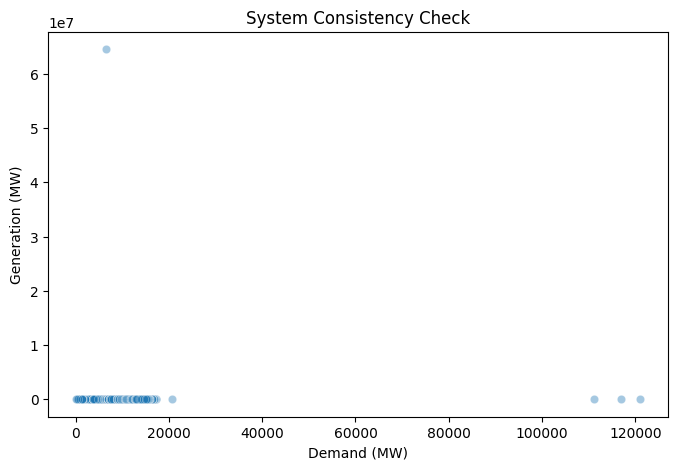

In [73]:
# core physical check
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['demand_mw'],y=df['gen_total_mw'],alpha=0.4)

plt.title("System Consistency Check")
plt.xlabel("Demand (MW)")
plt.ylabel("Generation (MW)")
plt.show()

In [74]:
# Electricity supply
df['available_supply'] = (
    df['total_generation_sources_mw'] +
    df['import_electricity_mw']
)

In [75]:
# Consistency
df['power_balance_error'] = (
    df['demand_mw'] - (df['available_supply'] + df['load_shedding_mw'])
)

In [76]:
df.head()

,gen_total_mw,demand_mw,load_shedding_mw,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour,remarks,month_name,day_name,weekly_holiday,weather_condition,import_electricity_mw,total_generation_sources_mw,available_supply,power_balance_error
datetime,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,5913.0,5913.0,0.0,18.3,74.0,0.0,3.5,0.0,Night_OffPeak,January,Wednesday,No,cold,205.0,5700.0,5905.0,8.0
2020-01-01 01:00:00,5570.0,5570.0,0.0,16.5,81.0,0.0,6.0,1.0,Night_OffPeak,January,Wednesday,No,cold,203.0,5324.0,5527.0,43.0
2020-01-01 02:00:00,5351.0,5351.0,0.0,14.6,89.0,0.0,8.4,2.0,Night_OffPeak,January,Wednesday,No,cold,201.0,5106.0,5307.0,44.0
2020-01-01 03:00:00,5223.0,5223.0,0.0,14.5,90.0,0.0,6.3,3.0,Night_OffPeak,January,Wednesday,No,cold,199.0,4979.0,5178.0,45.0
2020-01-01 04:00:00,5142.0,5142.0,0.0,14.1,90.0,0.0,8.2,4.0,Night_OffPeak,January,Wednesday,No,cold,197.0,4902.0,5099.0,43.0


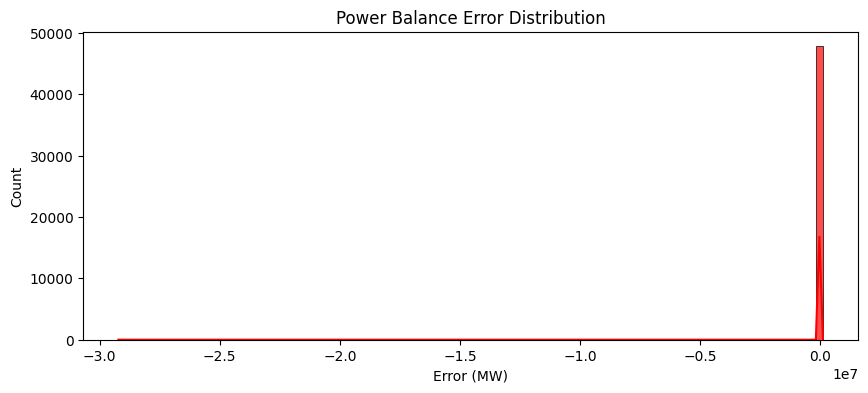

In [77]:
# power balance error
plt.figure(figsize=(10,4))

sns.histplot(df['power_balance_error'], bins=100, kde=True, color='red', alpha=0.7)

plt.title("Power Balance Error Distribution")
plt.xlabel("Error (MW)")
plt.show()

In [78]:
# Check Interpretation
print(f"Corrent system : {df[df['power_balance_error'].abs() < 0.01].shape}")
print(f"Demand not met : {df[df['power_balance_error'] > 0].shape}")
print(f"Over Reporting : {df[df['power_balance_error'] < 0].shape}")

Corrent system : (8128, 17)
Demand not met : (13752, 17)
Over Reporting : (25896, 17)


In [79]:
# real anomaly detects
anomaly_rows = df[
    df['power_balance_error'].abs() > df['demand_mw'] * 0.3
]
anomaly_rows.shape

(170, 17)

In [80]:
# mismatch 
df['gen_mismatch'] = (
    df['gen_total_mw'] - df['available_supply']
)

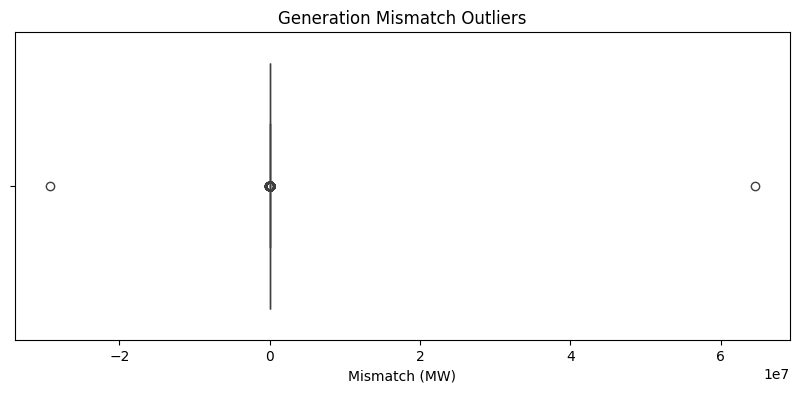

In [81]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df['gen_mismatch'])

plt.title("Generation Mismatch Outliers")
plt.xlabel("Mismatch (MW)")
plt.show()

In [82]:
outliers = df[df['gen_mismatch'].abs() > 15000]

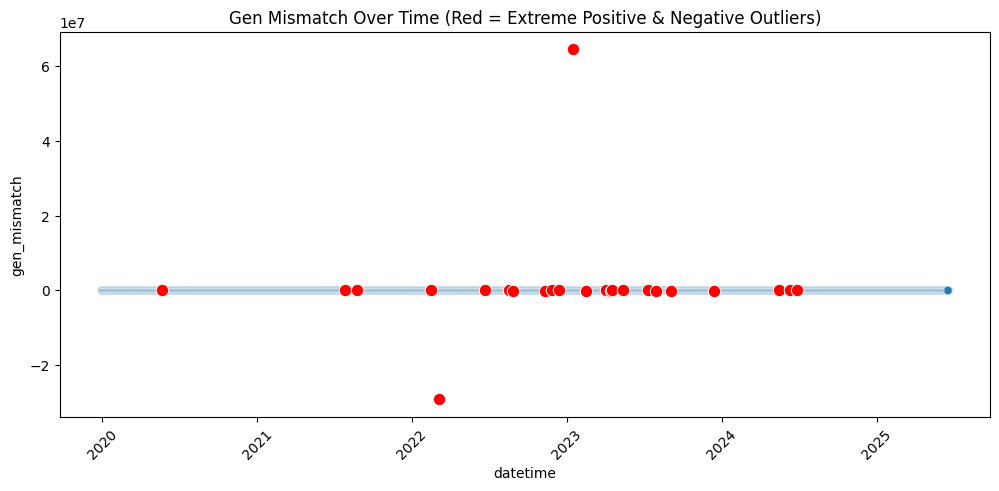

In [83]:
plt.figure(figsize=(12,5))

# full data
sns.scatterplot(
    x=df.index,
    y=df['gen_mismatch'],
    alpha=0.3
)

# outliers
sns.scatterplot(
    x=outliers.index,
    y=outliers['gen_mismatch'],
    color='red',
    s=80
)

plt.title("Gen Mismatch Over Time (Red = Extreme Positive & Negative Outliers)")
plt.xticks(rotation=45)
plt.show()

In [84]:
df = df[df['gen_mismatch'].abs() <= 15000]

### Decision Summary
During analysis,extreme outlier was found where the difference between gen_total_mw and (generation sources + imports) exceeded 15,000 MW. Those values are physically unrealistic for the Bangladesh power system and indicates a data error rather than a real operational event.

In [85]:
df = df[
    (df['available_supply'] < 20000) &
    (df['demand_mw'] > 1000) &
    (df['gen_total_mw'] < 20000) 
]

In [86]:
# drop unnecessary columns
df = df.drop(columns=[
    'power_balance_error',
    'gen_mismatch'
])

## Train-Test Split in Time Series

In [87]:
# split data into train and test set
train_size = int(len(df) *0.8)

train_set = df.iloc[:train_size]
test_set = df.iloc[train_size:]

In [88]:
train_set.shape, test_set.shape

((38188, 16), (9548, 16))

In [89]:
# start and end time of those sets
print(f"Train Set : Start time - {train_set.index[0]}, End time - {train_set.index[-1]}")
print(f"Test Set : Start time - {test_set.index[0]}, End time - {test_set.index[-1]}")

Train Set : Start time - 2020-01-01 00:00:00, End time - 2024-05-14 10:00:00
Test Set : Start time - 2024-05-14 12:00:00, End time - 2025-06-17 00:00:00


### In time series forecasting, split data based on **time order** not randomly.
---

**Train Set (Past Data) :** The train set contains historical data that is used to teach the model patterns in electricity demand. it's helps model for:
- Learn trends and seasonality
- Build lag and rolling features
- Train forecasting models
- Understand system behavior

in my dataset, it contains 80% of data, start time `2020-01-01 00:00:00` end time `2024-05-14 10:00:00`

---
**Test Set (Future Data) :** The test set contains later time periods that simulate unseen future data. Purpose:
- Evaluate model performance on unseen data
- Simulate real-world forecasting scenario
- Check generalization ability

in my dataset, it contains 20% of data, start time `2024-05-14 12:00:00` end time `2025-06-17 00:00:00`

---
*Train = past learning*  
*Test = future prediction*

## Univariant EDA

### Electricity Demand Over time

In [90]:
train_set['demand_mw'].describe()

count     38188.000000
mean       9781.829711
std        2424.810958
min        1005.000000
25%        8043.000000
50%        9664.000000
75%       11443.000000
max      121000.000000
Name: demand_mw, dtype: float64

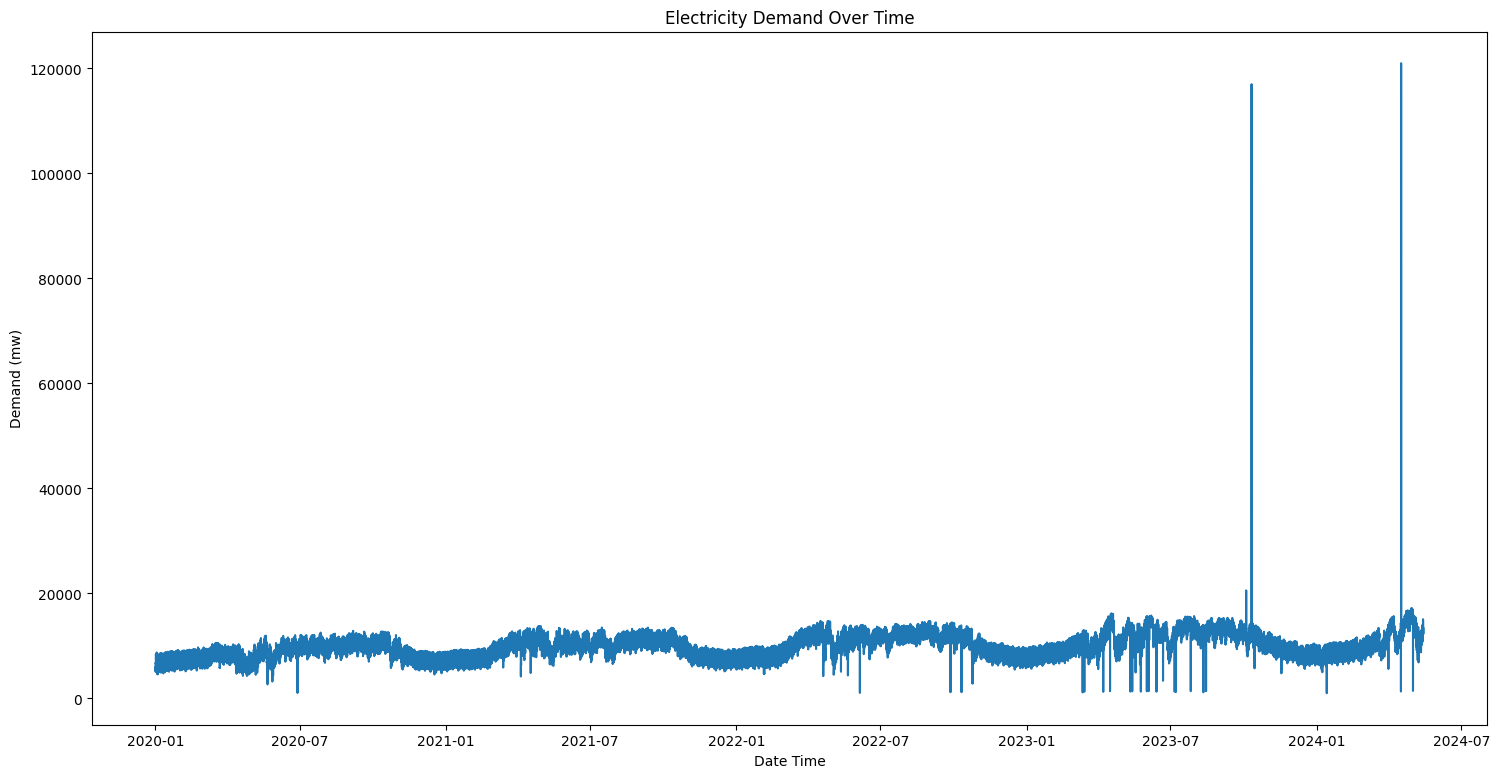

In [91]:
plt.figure(figsize=(18,9))
plt.plot(train_set.index, train_set['demand_mw'])
plt.title("Electricity Demand Over Time")
plt.xlabel("Date Time")
plt.ylabel("Demand (mw)")
plt.show()

### Outlier Detection in `demand_mw`

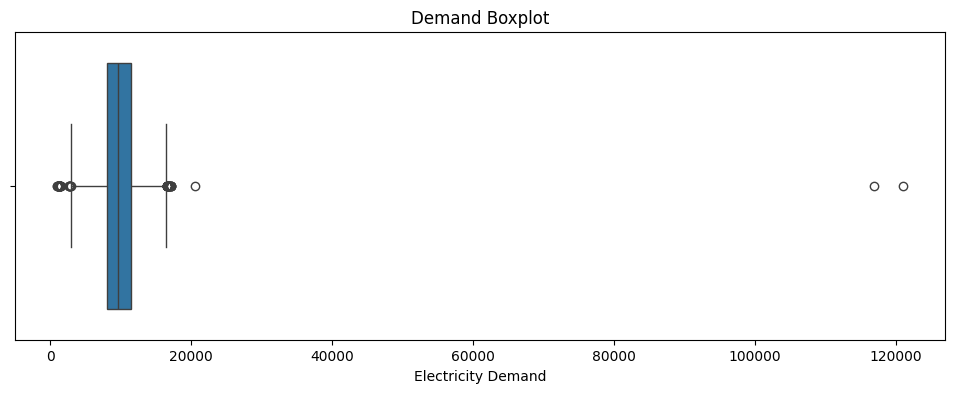

In [92]:
plt.figure(figsize=(12,4))
sns.boxplot(x=train_set['demand_mw'])
plt.title('Demand Boxplot')
plt.xlabel("Electricity Demand")

plt.show()

**Key Observation:** *There is a very large gap between max and normal values, 75% of data is below 11,500 MW,But maximum value is 121,000 MW. This is a clear sign of extreme outliers or data inconsistency .*

### STL Decomposition

In [93]:
from statsmodels.tsa.seasonal import STL

In [94]:
y = train_set['demand_mw']
stl = STL(y, period=24, robust=True)
result = stl.fit()

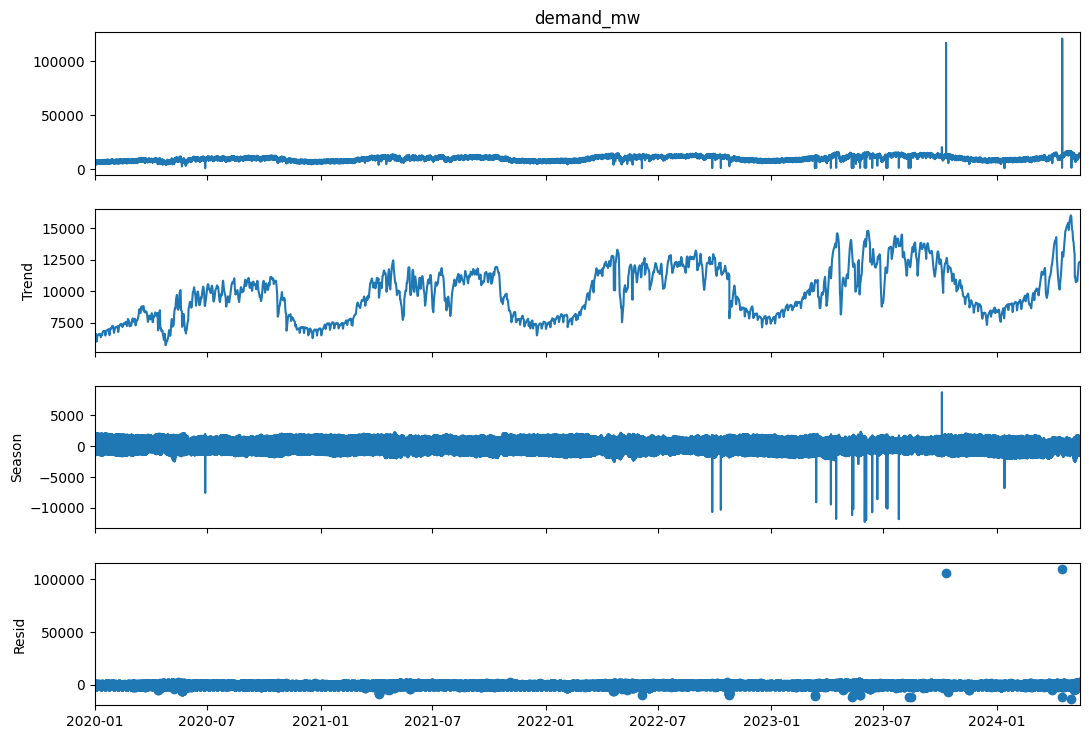

In [95]:
fig = result.plot()
fig.set_size_inches(12, 8)
plt.show()

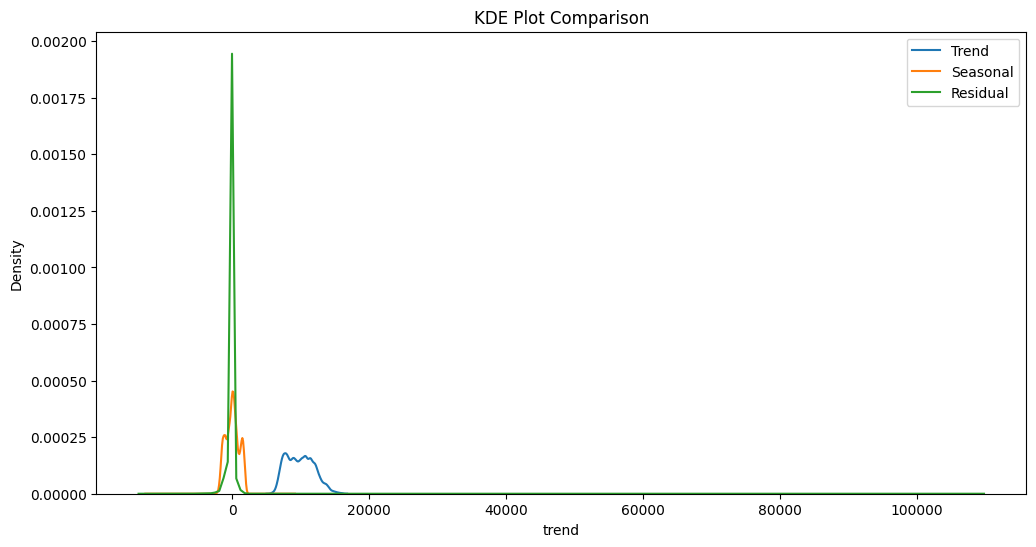

In [96]:
plt.figure(figsize=(12,6))

sns.kdeplot(result.trend, label='Trend')
sns.kdeplot(result.seasonal, label='Seasonal')
sns.kdeplot(result.resid, label='Residual')

plt.legend()
plt.title("KDE Plot Comparison")
plt.show()

### STL (Seasonal-Trend decomposition) summary:

1. Trend (long-term movement):
   - Demand is increasing over years.
   - There are slow cycles (rise → fall → rise).
   - This is not daily noise, it is structural change.
2. Seasonal (repeating pattern):
   - consistent oscillation around zero.
   - STL successfully removed trend and isolated repeating daily pattern.
3. Residual (left):
   - Huge spikes, these are not normal pattern (Outlier problem)
   

In [97]:
# check any negative value in `demand_mw`
(train_set['demand_mw']<0).any()

np.False_

In [98]:
train_set.groupby('weather_condition')['demand_mw'].mean()

weather_condition
cold         7948.988137
heatwave    11402.452385
normal      10100.408188
Name: demand_mw, dtype: float64

In [99]:
# Top 2 rows with highest electricity demand
train_set.nlargest(2, 'demand_mw')

,gen_total_mw,demand_mw,load_shedding_mw,temp_c,humidity_pct,rain_mm,wind_speed_ms,hour,remarks,month_name,day_name,weekly_holiday,weather_condition,import_electricity_mw,total_generation_sources_mw,available_supply
datetime,,,,,,,,,,,,,,,,
2024-04-16 07:00:00,11701.0,121000.0,381.0,28.0,73.0,0.0,5.2,7.0,Day_Peak,April,Tuesday,No,normal,1024.0,10677.0,11701.0
2023-10-11 03:00:00,11468.0,117000.0,222.0,25.1,95.0,0.0,6.4,3.0,Night_OffPeak,October,Wednesday,No,normal,1057.0,10411.0,11468.0


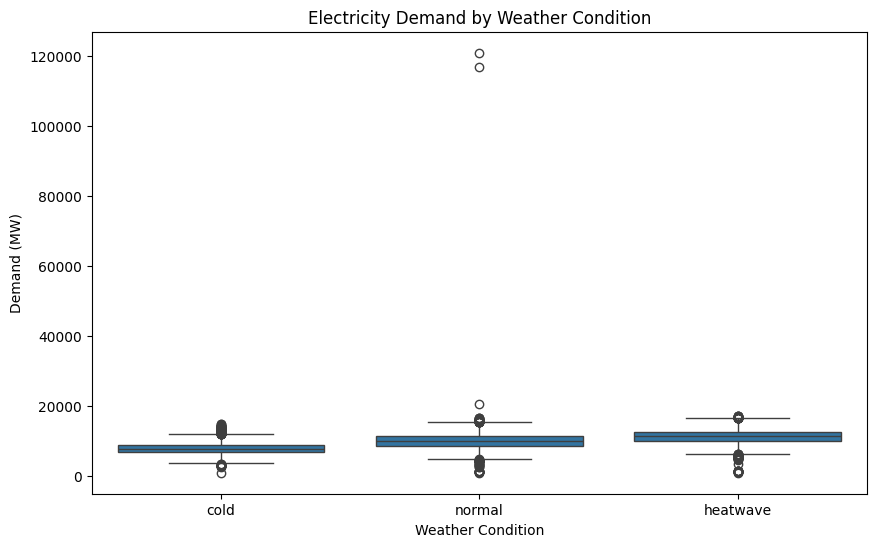

In [100]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train_set,
    x='weather_condition',
    y='demand_mw'
)

plt.title('Electricity Demand by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Demand (MW)')

plt.show()

In [101]:
# Removes impossible (extreme) anomalies
train_set = train_set[train_set['demand_mw'] < 50000]

In [102]:
# Sort index
train_set = train_set.sort_index()

In [103]:
train_set.shape

(38186, 16)

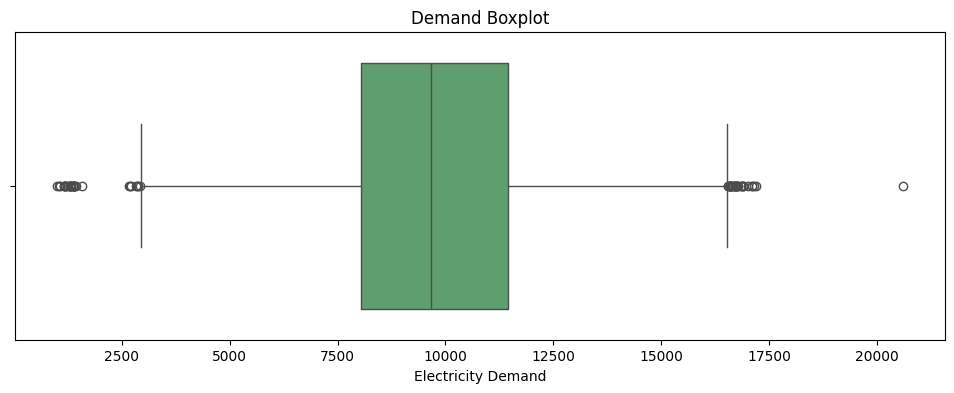

In [104]:
# recheck outlier 
plt.figure(figsize=(12,4))
sns.boxplot(x=train_set['demand_mw'],color='#55A868')
plt.title('Demand Boxplot')
plt.xlabel("Electricity Demand")

plt.show()

## Outlier Handling Approach

Removed only extreme outliers because they are most likely data errors or unrealistic spikes that can mislead the model. However, I kept moderate outliers since they often represent real system behavior such as peak demand, load shedding, or seasonal and weather-driven changes. These patterns are important for forecasting electricity demand accurately, so removing them would cause loss of useful information. Also, I observed that even some extreme values are aligned with normal weather conditions. 

In [105]:
train_set.columns

Index(['gen_total_mw', 'demand_mw', 'load_shedding_mw', 'temp_c',
       'humidity_pct', 'rain_mm', 'wind_speed_ms', 'hour', 'remarks',
       'month_name', 'day_name', 'weekly_holiday', 'weather_condition',
       'import_electricity_mw', 'total_generation_sources_mw',
       'available_supply'],
      dtype='object')

In [106]:
train_set.dtypes

gen_total_mw                   float64
demand_mw                      float64
load_shedding_mw               float64
temp_c                         float64
humidity_pct                   float64
rain_mm                        float64
wind_speed_ms                  float64
hour                           float64
remarks                         object
month_name                      object
day_name                        object
weekly_holiday                  object
weather_condition               object
import_electricity_mw          float64
total_generation_sources_mw    float64
available_supply               float64
dtype: object

## Weather Related Data Analysis

In [107]:
train_set['temp_c'].describe()

count    38186.000000
mean        25.334471
std          5.363871
min          8.600000
25%         22.000000
50%         26.500000
75%         29.000000
max         40.800000
Name: temp_c, dtype: float64

In [108]:
train_set['humidity_pct'].describe()

count    38186.000000
mean        76.275860
std         16.499516
min         15.000000
25%         67.000000
50%         80.000000
75%         90.000000
max        100.000000
Name: humidity_pct, dtype: float64

In [109]:
train_set['rain_mm'].describe()

count    38186.000000
mean         0.191023
std          0.893410
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         39.500000
Name: rain_mm, dtype: float64

In [110]:
train_set['wind_speed_ms'].describe()

count    38186.000000
mean         9.257406
std          4.823680
min          0.000000
25%          6.100000
50%          8.100000
75%         11.500000
max         40.100000
Name: wind_speed_ms, dtype: float64

*The weather-related features appear realistic and consistent with Bangladesh climate conditions. Although some variables such as rainfall and wind speed contain extreme values, these are likely due to natural weather variability rather than data corruption. Therefore, no major outlier treatment was applied to weather features.*

## Remaining Outlier Inspection

In [111]:
columns_to_check =[
    'gen_total_mw','load_shedding_mw'
]

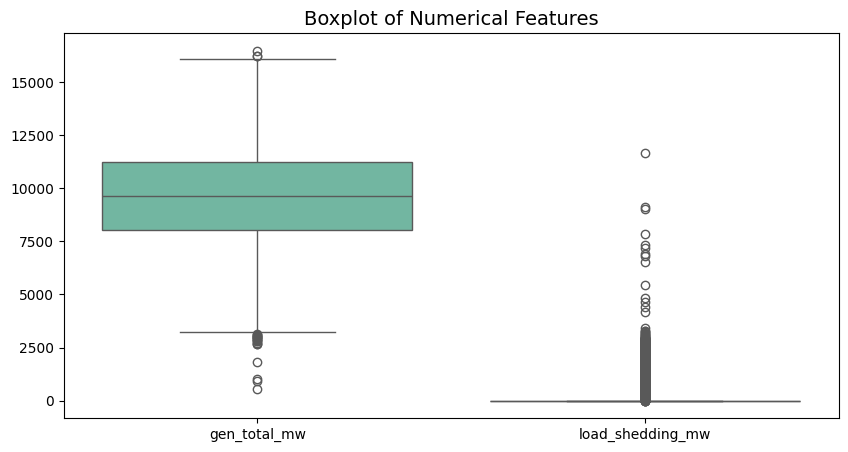

In [112]:
# Outlier Detections 
plt.figure(figsize=(10,5))

sns.boxplot(
    data=train_set[columns_to_check],
    palette='Set2'
)

plt.title('Boxplot of Numerical Features', fontsize=14)

plt.show()

### Load Shedding Data Analysis

In [113]:
train_set['load_shedding_mw'].describe()

count    38186.000000
mean       139.894739
std        397.225008
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      11672.000000
Name: load_shedding_mw, dtype: float64

In [114]:
train_set['temp_load_shedding']=train_set['demand_mw'] - train_set['available_supply']

In [115]:
# differences
train_set['error_load_shedding'] = train_set['load_shedding_mw'] - train_set['temp_load_shedding']

In [116]:
train_set['error_load_shedding'].describe()

count    38186.000000
mean        13.211156
std        415.635729
min      -9950.000000
25%          0.000000
50%         10.000000
75%         15.000000
max      12917.000000
Name: error_load_shedding, dtype: float64

In [117]:
# error calculate
mae = train_set['error_load_shedding'].abs().mean()
print("Mean Absolute Error:", mae)

Mean Absolute Error: 50.29700989891584


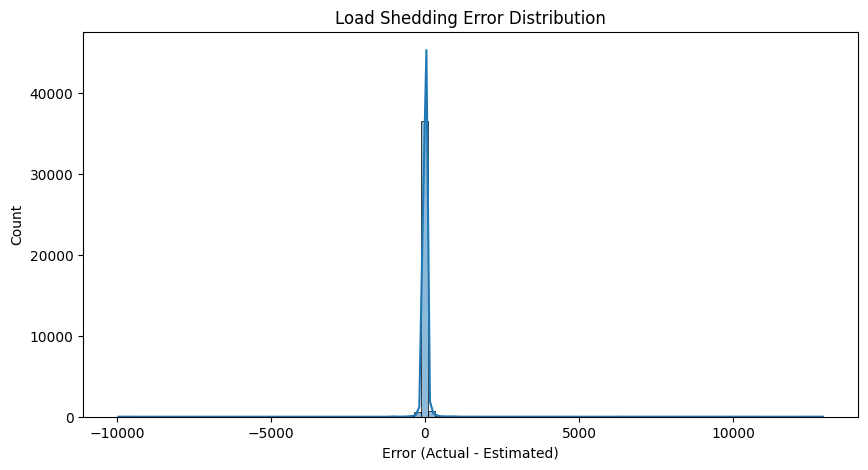

In [118]:
plt.figure(figsize=(10,5))

sns.histplot(train_set['error_load_shedding'], bins=100, kde=True)

plt.title("Load Shedding Error Distribution")

plt.xlabel("Error (Actual - Estimated)")

plt.show()

In [119]:
# extreme cases
extreme_errors = train_set[abs(train_set['error_load_shedding']) > train_set['error_load_shedding'].std() * 3]
extreme_errors[[ 'demand_mw', 'available_supply', 
                'load_shedding_mw', 'temp_load_shedding', 'error_load_shedding']]

,demand_mw,available_supply,load_shedding_mw,temp_load_shedding,error_load_shedding
datetime,,,,,
2020-01-26 16:00:00,7044.0,11896.1,0.0,-4852.1,4852.1
2020-02-09 09:00:00,7738.0,17316.4,0.0,-9578.4,9578.4
2020-02-15 07:00:00,7139.0,13444.1,0.0,-6305.1,6305.1
2020-03-05 06:00:00,6902.0,13808.0,0.0,-6906.0,6906.0
2020-03-13 03:00:00,7405.0,1904.0,0.0,5501.0,-5501.0
...,...,...,...,...,...
2024-04-16 01:00:00,1330.0,12803.0,475.0,-11473.0,11948.0
2024-04-19 19:00:00,14260.0,7452.0,227.0,6808.0,-6581.0
2024-05-01 05:00:00,1440.0,13443.0,914.0,-12003.0,12917.0


In [120]:
print(f"Percentage of error: {np.round((len(extreme_errors)/len(train_set))*100, 2)}%")

Percentage of error: 0.46%


In [121]:
extreme_errors['weather_condition'].value_counts()

weather_condition
normal      66
heatwave    60
cold        48
Name: count, dtype: int64

#### About `load_shedding_mw`:
- Low mismatch rate 0.46%
- Small error (MAE,50 MW)
- Errors are spread across all weather conditions (normal, heatwave, cold)

so, keep original one

In [122]:
train_set = train_set.sort_index()

In [123]:
train_set.index.inferred_freq

In [124]:
time_diff = train_set.index.to_series().diff()

print(time_diff.value_counts().head(10))

datetime
0 days 01:00:00    38083
0 days 02:00:00       99
0 days 03:00:00        3
Name: count, dtype: int64


In [125]:
full_index = pd.date_range(
    start=train_set.index.min(),
    end=train_set.index.max(),
    freq='H'
)

C:\Users\dclid\AppData\Local\Temp\ipykernel_12208\1729886024.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_index = pd.date_range(


In [126]:
# reindex 
train_set = train_set.reindex(full_index)
train_set.index.name = "datetime"

In [127]:
# check hourly missing ratio
missing_ratio = train_set.isna().mean().sort_values(ascending=False)
print(missing_ratio.head(10))

gen_total_mw                   0.002742
demand_mw                      0.002742
temp_load_shedding             0.002742
available_supply               0.002742
total_generation_sources_mw    0.002742
import_electricity_mw          0.002742
weather_condition              0.002742
weekly_holiday                 0.002742
day_name                       0.002742
month_name                     0.002742
dtype: float64


**Apply Time-based interpolation**

In [128]:
train_set = train_set.interpolate(method='time')

C:\Users\dclid\AppData\Local\Temp\ipykernel_12208\2516842843.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  train_set = train_set.interpolate(method='time')


In [129]:
train_set = train_set.ffill().bfill()

In [130]:
train_set.index.to_series().diff().value_counts().head()

datetime
0 days 01:00:00    38290
Name: count, dtype: int64

In [131]:
train_set.shape

(38291, 18)

### Rolling Trend Visualization

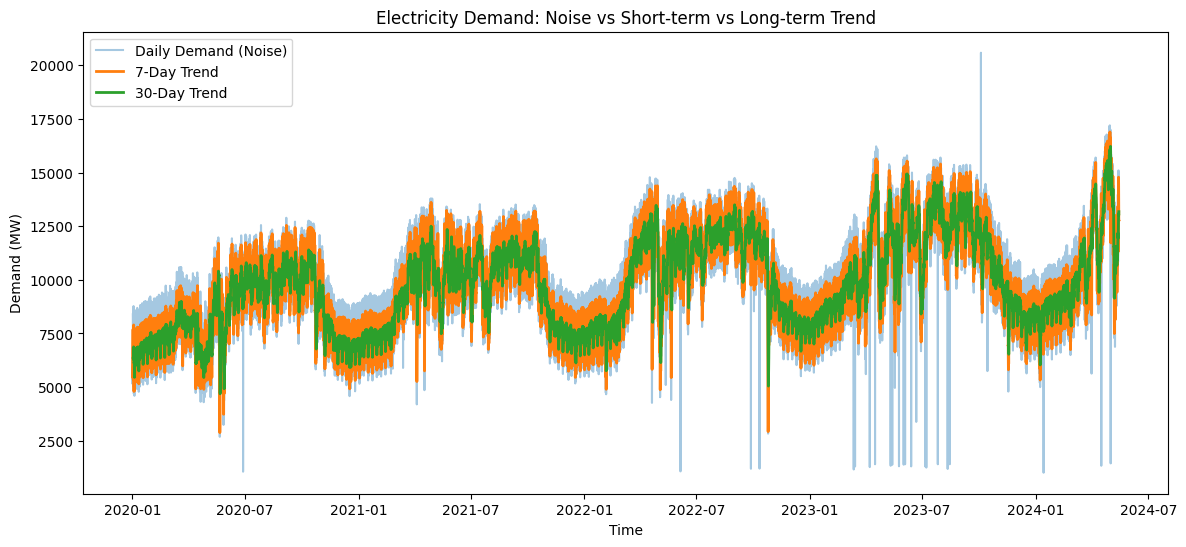

In [132]:
train_set['rolling_7'] = train_set['demand_mw'].rolling(window=7).mean()
train_set['rolling_30'] = train_set['demand_mw'].rolling(window=30).mean()

plt.figure(figsize=(14,6))

# Raw demand (noise)
plt.plot(train_set.index, train_set['demand_mw'], alpha=0.4, label="Daily Demand (Noise)")

# Short-term trend
plt.plot(train_set.index, train_set['rolling_7'], linewidth=2, label="7-Day Trend")

# Long-term trend
plt.plot(train_set.index, train_set['rolling_30'], linewidth=2, label="30-Day Trend")

plt.title("Electricity Demand: Noise vs Short-term vs Long-term Trend")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.legend()
plt.show()

### ADF Test

In [133]:
from statsmodels.tsa.stattools import adfuller

In [134]:
result = adfuller(train_set["demand_mw"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])

ADF Statistic: -6.3810144983363
p-value: 2.2223389508143712e-08
Critical Values: {'1%': np.float64(-3.4305210361717933), '5%': np.float64(-2.8616155939627768), '10%': np.float64(-2.566810236255487)}


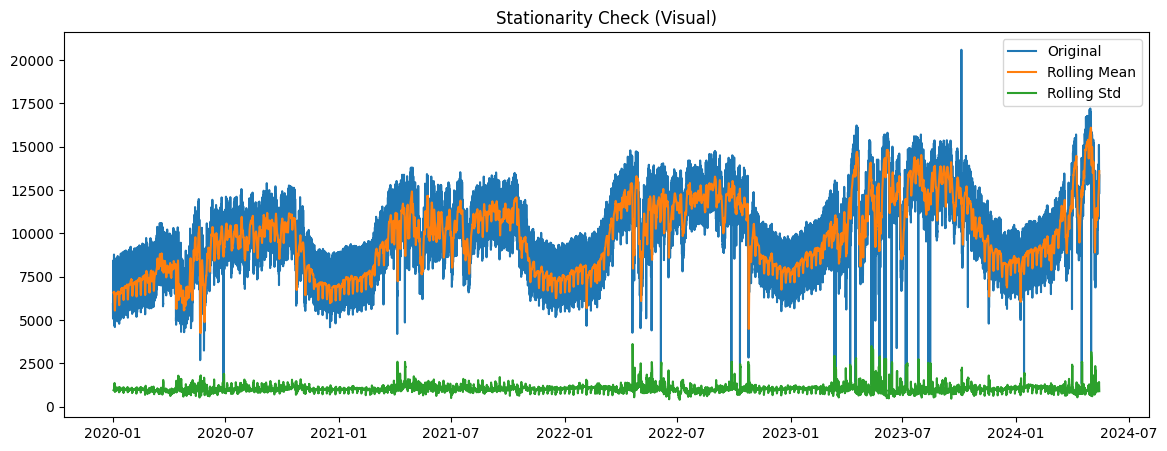

In [135]:
# Check stationarity visually
rolmean = train_set["demand_mw"].rolling(24).mean()
rolstd = train_set["demand_mw"].rolling(24).std()

plt.figure(figsize=(14,5))
plt.plot(train_set["demand_mw"], label="Original")
plt.plot(rolmean, label="Rolling Mean")
plt.plot(rolstd, label="Rolling Std")
plt.legend()
plt.title("Stationarity Check (Visual)")
plt.show()

**Interpretation**
- p-value < 0.05
- ADF statistic is smaller than all critical values

### Autocorrelation (ACF) & Partial Autocorrelation (PACF)

In [136]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

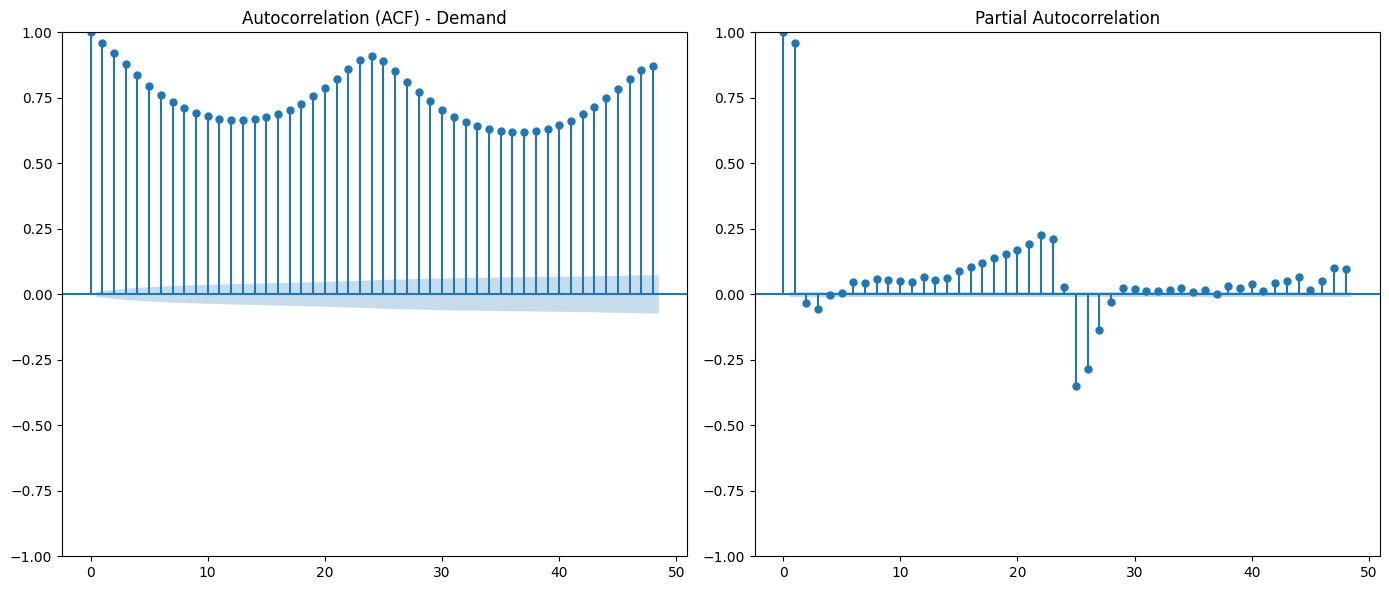

In [137]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plot_acf(train_set["demand_mw"].dropna(), lags=48, ax=plt.gca())
plt.title("Autocorrelation (ACF) - Demand")

plt.subplot(1,2,2)
plot_pacf(train_set["demand_mw"].dropna(), lags=48, ax=plt.gca(), method='ywm')

plt.tight_layout()
plt.show()

### Monthly Electricity Trend

In [138]:
monthly_demand = train_set["demand_mw"].resample("M").mean()

C:\Users\dclid\AppData\Local\Temp\ipykernel_12208\1268519925.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_demand = train_set["demand_mw"].resample("M").mean()


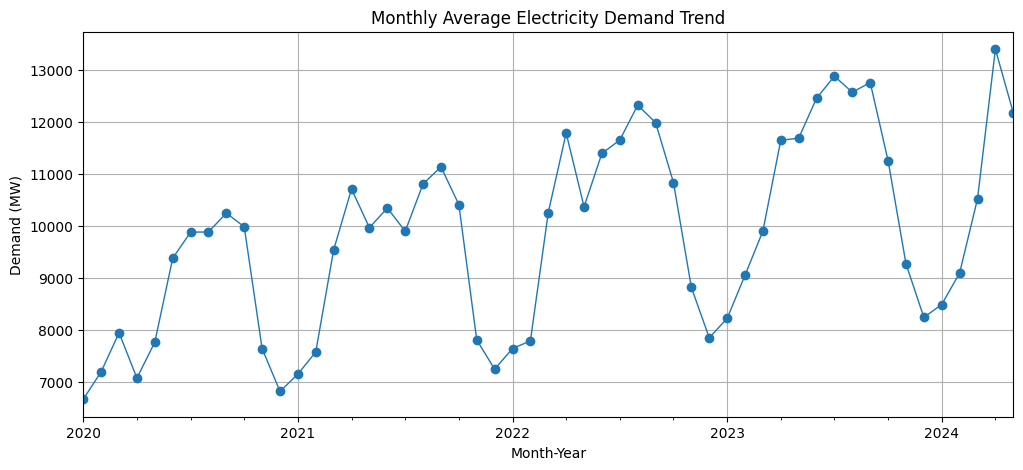

In [139]:
plt.figure(figsize=(12,5))
monthly_demand.plot(marker="o", linewidth=1)

plt.title("Monthly Average Electricity Demand Trend")
plt.xlabel("Month-Year")
plt.ylabel("Demand (MW)")

plt.grid(True)
plt.show()

In [140]:
print(f"Train set columns: {train_set.columns}\nTest set columns:{test_set.columns}")

Train set columns: Index(['gen_total_mw', 'demand_mw', 'load_shedding_mw', 'temp_c',
       'humidity_pct', 'rain_mm', 'wind_speed_ms', 'hour', 'remarks',
       'month_name', 'day_name', 'weekly_holiday', 'weather_condition',
       'import_electricity_mw', 'total_generation_sources_mw',
       'available_supply', 'temp_load_shedding', 'error_load_shedding',
       'rolling_7', 'rolling_30'],
      dtype='object')
Test set columns:Index(['gen_total_mw', 'demand_mw', 'load_shedding_mw', 'temp_c',
       'humidity_pct', 'rain_mm', 'wind_speed_ms', 'hour', 'remarks',
       'month_name', 'day_name', 'weekly_holiday', 'weather_condition',
       'import_electricity_mw', 'total_generation_sources_mw',
       'available_supply'],
      dtype='object')


In [141]:
train_set = train_set.drop(columns=['temp_load_shedding', 'error_load_shedding','rolling_7','rolling_30'])

In [142]:
train_set.shape, test_set.shape

((38291, 16), (9548, 16))

In [143]:
train_set.columns


Index(['gen_total_mw', 'demand_mw', 'load_shedding_mw', 'temp_c',
       'humidity_pct', 'rain_mm', 'wind_speed_ms', 'hour', 'remarks',
       'month_name', 'day_name', 'weekly_holiday', 'weather_condition',
       'import_electricity_mw', 'total_generation_sources_mw',
       'available_supply'],
      dtype='object')

# Model Evaluation

In [144]:
train_set.columns

Index(['gen_total_mw', 'demand_mw', 'load_shedding_mw', 'temp_c',
       'humidity_pct', 'rain_mm', 'wind_speed_ms', 'hour', 'remarks',
       'month_name', 'day_name', 'weekly_holiday', 'weather_condition',
       'import_electricity_mw', 'total_generation_sources_mw',
       'available_supply'],
      dtype='object')

## XGBoost (ML Model)

In [145]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [146]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [147]:
# split data for model
X_train = train_set.drop(columns=['demand_mw','available_supply','hour'])
y_train = train_set['demand_mw']

X_test = test_set.drop(columns=['demand_mw','available_supply','hour'])
y_test = test_set['demand_mw']

In [148]:
X_train.shape, y_train.shape

((38291, 13), (38291,))

In [149]:
X_test.shape, y_test.shape

((9548, 13), (9548,))

In [150]:
X_train.dtypes

gen_total_mw                   float64
load_shedding_mw               float64
temp_c                         float64
humidity_pct                   float64
rain_mm                        float64
wind_speed_ms                  float64
remarks                         object
month_name                      object
day_name                        object
weekly_holiday                  object
weather_condition               object
import_electricity_mw          float64
total_generation_sources_mw    float64
dtype: object

In [151]:
categorical_cols = [
    'remarks',
    'month_name',
    'day_name',
    'weekly_holiday',
    'weather_condition'
]

### Apply One-Hot-Encoding for categorical columns

In [152]:
# preprocessor for encoding 
preprocessor = ColumnTransformer(
    transformers =[
     ('cat',OneHotEncoder(handle_unknown='ignore'),categorical_cols)
    ],
    remainder='passthrough'
)

In [153]:
# Model 
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

### ML Pipeline

In [154]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb)
])

In [155]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [156]:
# prediction
y_pred = model.predict(X_test)

In [157]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("MAPE:", mape)

MAE : 194.58661241535367
RMSE: 1099.4062700485629
R2  : 0.802013005720028
MAPE: 1.8072449245104598


### Model Performance Summary
- MAE: 194.59 MW, average absolute prediction error.
- RMSE: 1099.41 MW, higher error sensitivity for large spikes.
- R2: 0.802, explains ~80% variance in demand.
- MAPE: 1.81%, very low percentage error, strong accuracy.

Overall, the model performs well with good accuracy and strong explanatory power. However, the relatively higher RMSE suggests occasional large prediction errors, which may come from peak demand spikes or unusual system conditions.

## Prophet (Statistical time series model)

In [158]:
!pip install prophet

Defaulting to user installation because normal site-packages is not writeable


In [159]:
from prophet import Prophet

**prepare data for prophet format**

In [160]:
train_prophet = train_set.reset_index()[[
    'datetime',
    'demand_mw',
    'temp_c',
    'humidity_pct',
    'load_shedding_mw'
]]

train_prophet = train_prophet.rename(columns={
    'datetime': 'ds',
    'demand_mw': 'y'
})

train_prophet['ds'] = pd.to_datetime(train_prophet['ds'])

In [161]:
train_prophet.dtypes

ds                  datetime64[ns]
y                          float64
temp_c                     float64
humidity_pct               float64
load_shedding_mw           float64
dtype: object

In [162]:
future = pd.DataFrame(index=test_set.index)
future['ds'] = future.index
future['ds'] = pd.to_datetime(future['ds'])

In [163]:
future['temp_c'] = test_set['temp_c']
future['humidity_pct'] = test_set['humidity_pct']
future['load_shedding_mw'] = test_set['load_shedding_mw']

In [164]:
future.dtypes

ds                  datetime64[ns]
temp_c                     float64
humidity_pct               float64
load_shedding_mw           float64
dtype: object

In [173]:
# model 
model = Prophet(
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

In [174]:
# add hourly pattern
model.add_seasonality(
    name='hourly_pattern',
    period=24,
    fourier_order=20
)

In [175]:
model.add_regressor('temp_c')
model.add_regressor('humidity_pct')
model.add_regressor('load_shedding_mw')

In [176]:
model.fit(train_prophet)

13:36:47 - cmdstanpy - INFO - Chain [1] start processing
13:38:05 - cmdstanpy - INFO - Chain [1] done processing


In [177]:
# prediction
forecast = model.predict(future)

**Compare Actual vs Predicted**

In [178]:
result = test_set.reset_index()[['datetime', 'demand_mw']].merge(
    forecast[['ds', 'yhat']],
    left_on='datetime',
    right_on='ds',
    how='inner'
)
result.sample(5)

,datetime,demand_mw,ds,yhat
3725,2024-10-17 02:00:00,12390.0,2024-10-17 02:00:00,12381.635674
9172,2025-06-01 09:00:00,12432.0,2025-06-01 09:00:00,12496.960264
7299,2025-03-15 05:00:00,11195.0,2025-03-15 05:00:00,10671.470764
4593,2024-11-22 07:00:00,8009.0,2024-11-22 07:00:00,8909.147751
3148,2024-09-23 01:00:00,14900.0,2024-09-23 01:00:00,14658.219914


### Visualize prediction vs Reality

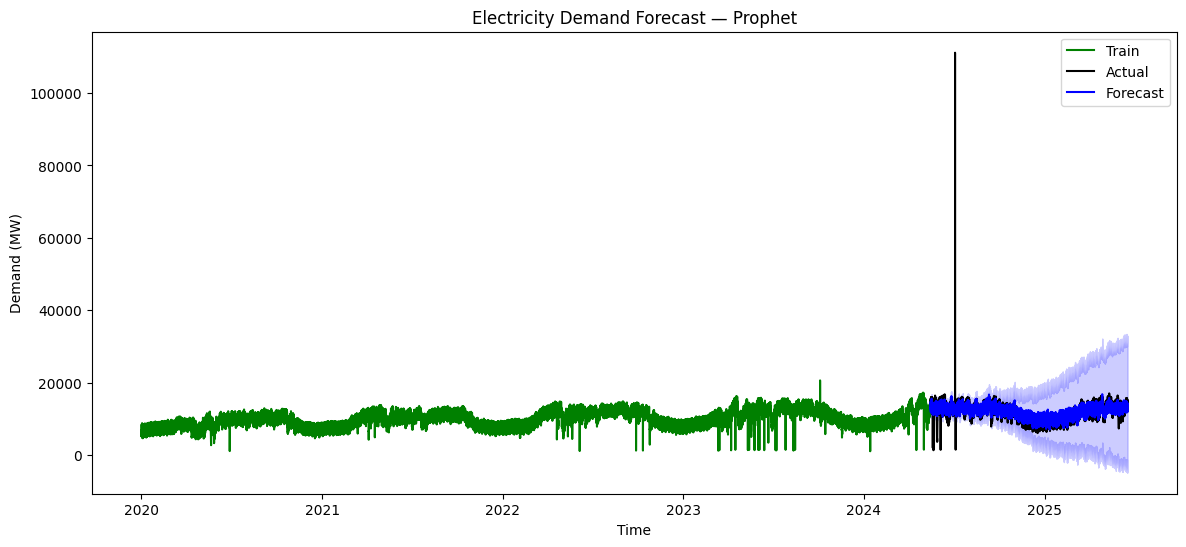

In [179]:
plt.figure(figsize=(14,6))

plt.plot(train_prophet["ds"], train_prophet["y"], label="Train", color="green")
plt.plot(test_set.reset_index()["datetime"], test_set["demand_mw"],label="Actual", color="black")
plt.plot(forecast["ds"], forecast["yhat"], label="Forecast", color="blue")
plt.fill_between(
    forecast["ds"],
    forecast["yhat_lower"],
    forecast["yhat_upper"],
    alpha=0.2,
    color="blue"
)

plt.legend()
plt.title("Electricity Demand Forecast — Prophet")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.show()

### Evaluation

In [188]:
mae = mean_absolute_error(result["demand_mw"], result["yhat"])
rmse = np.sqrt(mean_squared_error(result["demand_mw"], result["yhat"]))
r2 = r2_score(result["demand_mw"], result["yhat"])

# MAPE
mape = np.mean(
    np.abs((result["demand_mw"] - result["yhat"]) / result["demand_mw"])
) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("MAPE:", mape)

MAE : 913.2647442580604
RMSE: 1552.839978191751
R2  : 0.6050213231661401
MAPE: 8.713743154791368


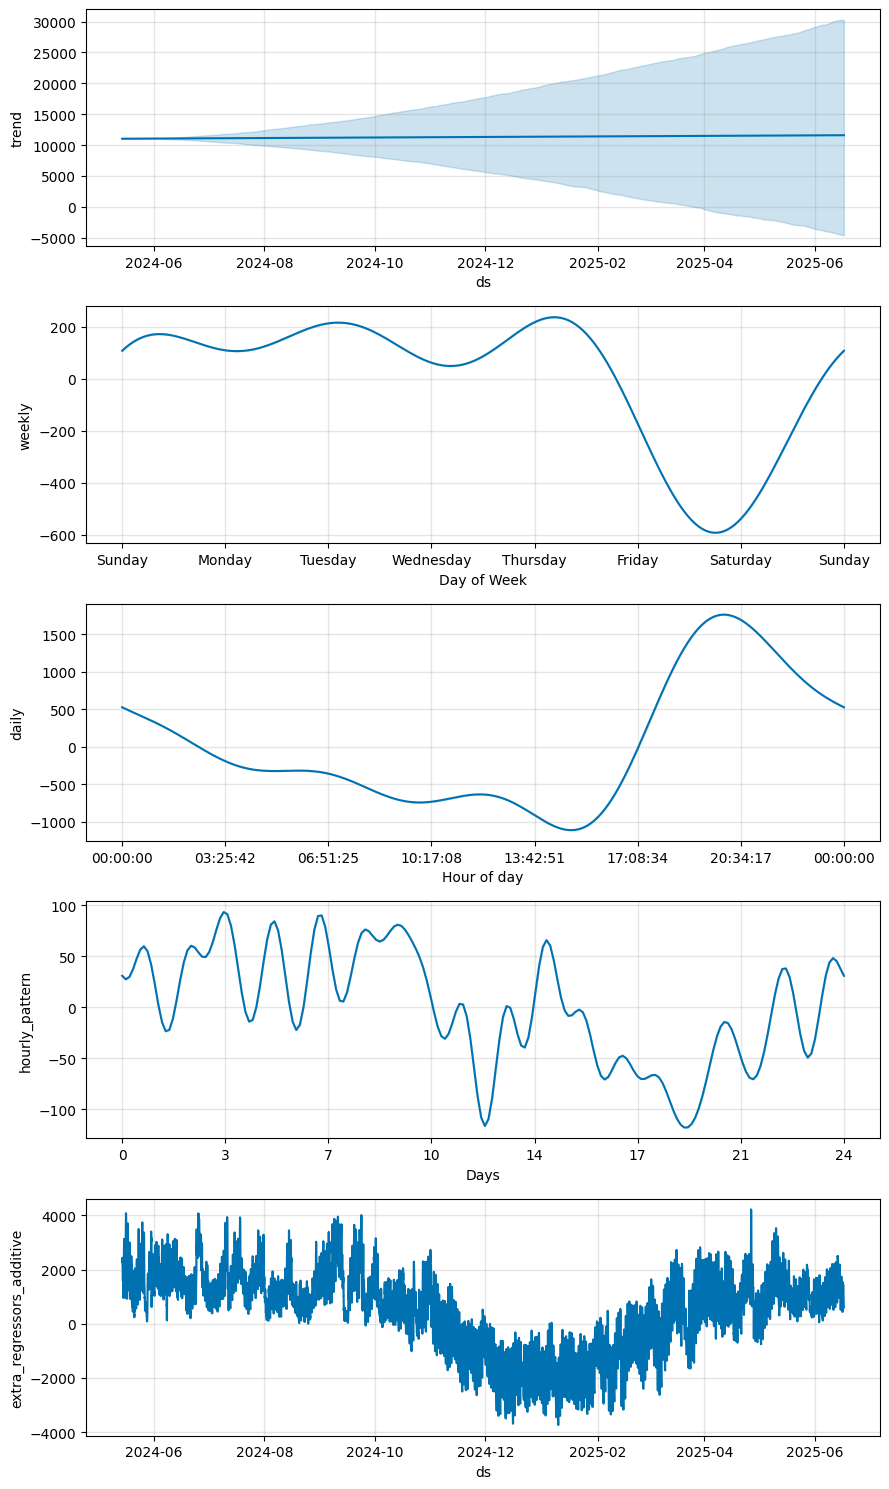

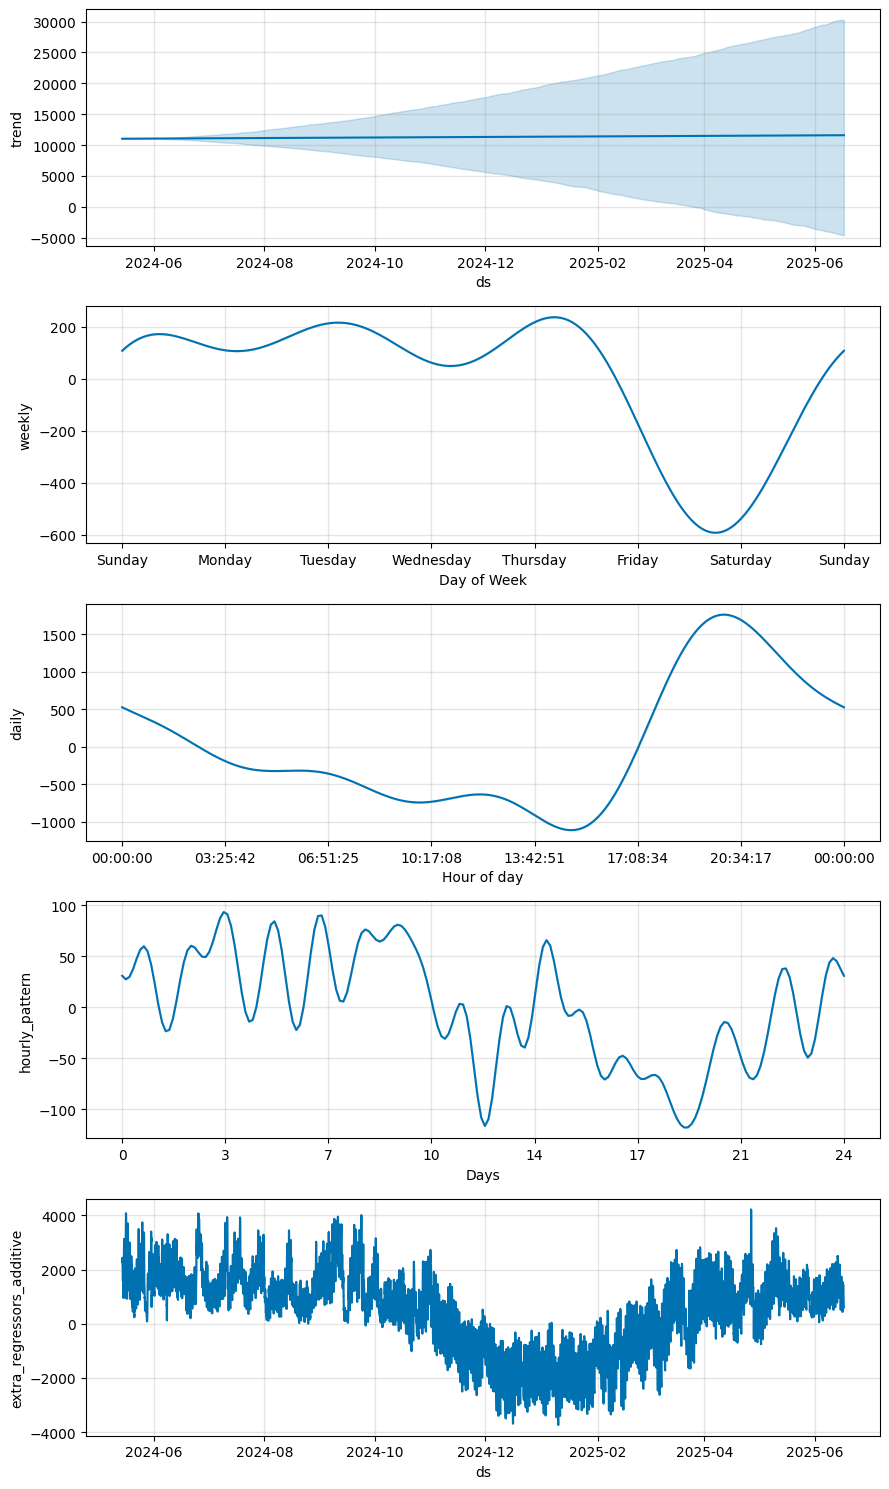

In [186]:
model.plot_components(forecast)

### Actual Vs Forecasting plot

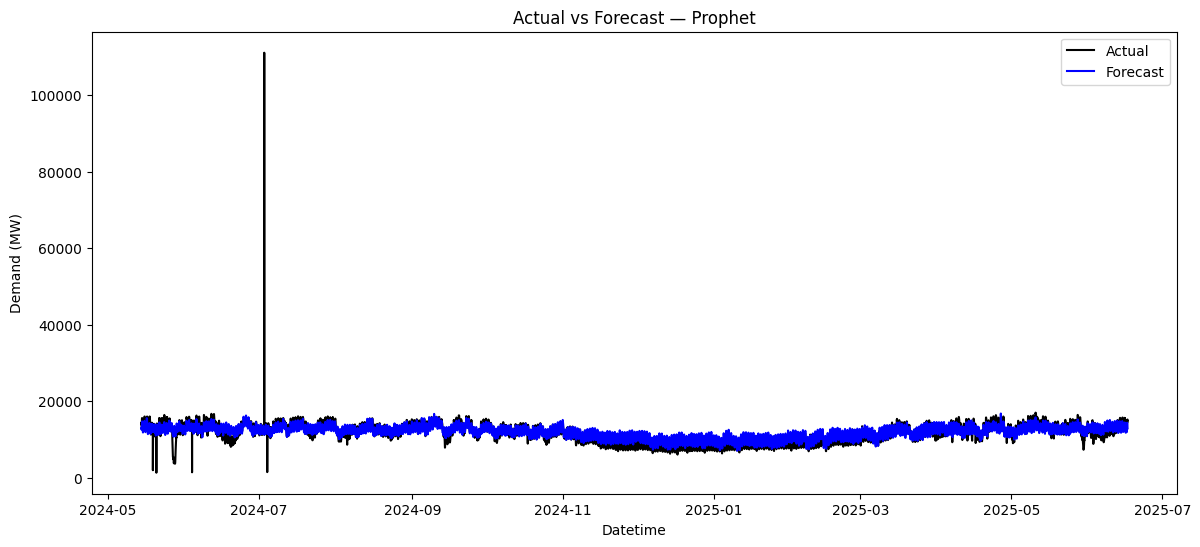

In [189]:
plt.figure(figsize=(14,6))

plt.plot(result["datetime"], result["demand_mw"],
         label="Actual", color="black")

plt.plot(result["datetime"], result["yhat"],
         label="Forecast", color="blue")

plt.legend()
plt.title("Actual vs Forecast — Prophet")
plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.show()

### Residual Analysis

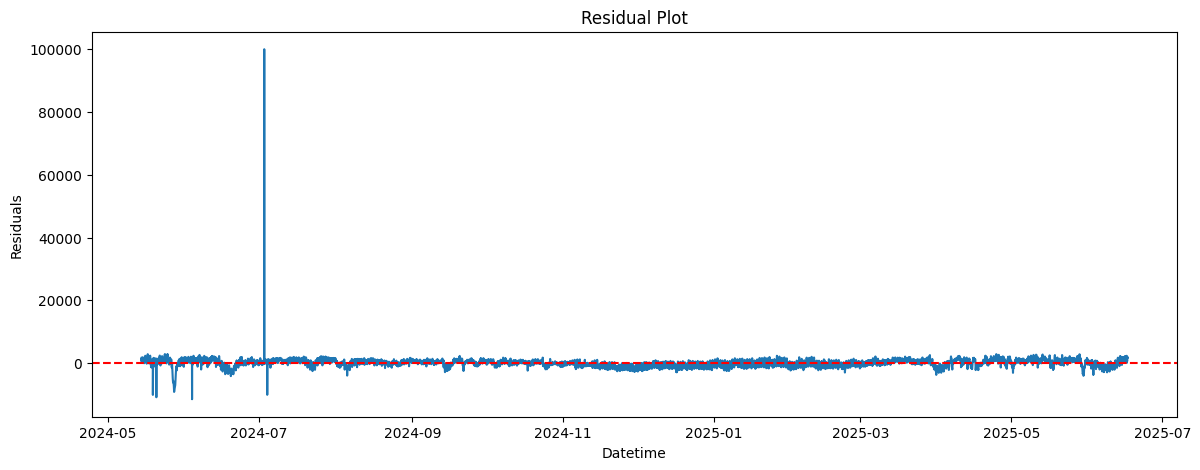

In [190]:
# residuals
result["residuals"] = result["demand_mw"] - result["yhat"]

plt.figure(figsize=(14,5))

plt.plot(result["datetime"], result["residuals"])

plt.axhline(0, color='red', linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Datetime")
plt.ylabel("Residuals")

plt.show()

In [193]:
# Error Percentage
error_percentage = (mae / result["demand_mw"].mean()) * 100
print("Average Error Percentage:", np.round(error_percentage,2))

Average Error Percentage: 7.77


In [194]:
result["absolute_error"] = abs(
    result["demand_mw"] - result["yhat"]
)

result.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,datetime,demand_mw,ds,yhat,residuals,absolute_error
1190,2024-07-03 05:00:00,111140.0,2024-07-03 05:00:00,11206.714172,99933.285828,99933.285828
492,2024-06-04 01:00:00,1400.0,2024-06-04 01:00:00,12853.530337,-11453.530337,11453.530337
147,2024-05-20 15:00:00,1290.0,2024-05-20 15:00:00,12119.972603,-10829.972603,10829.972603
113,2024-05-19 05:00:00,1945.0,2024-05-19 05:00:00,12020.852427,-10075.852427,10075.852427
1219,2024-07-04 10:00:00,1450.0,2024-07-04 10:00:00,11501.914822,-10051.914822,10051.914822
318,2024-05-27 19:00:00,4177.0,2024-05-27 19:00:00,13306.985548,-9129.985548,9129.985548
319,2024-05-27 20:00:00,4554.0,2024-05-27 20:00:00,13548.931318,-8994.931318,8994.931318
320,2024-05-27 21:00:00,4553.0,2024-05-27 21:00:00,13249.794256,-8696.794256,8696.794256
317,2024-05-27 18:00:00,4097.0,2024-05-27 18:00:00,12519.423512,-8422.423512,8422.423512
321,2024-05-27 22:00:00,4369.0,2024-05-27 22:00:00,12790.850598,-8421.850598,8421.850598


## LSTM (Deep Learning Model)

In [199]:
!pip install torch

Defaulting to user installation because normal site-packages is not writeable


In [200]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [201]:
features = [
    'demand_mw',
    'temp_c',
    'humidity_pct',
    'load_shedding_mw'
]

In [202]:
# train test data
train_data = train_set[features].copy()
test_data = test_set[features].copy()

In [204]:
from sklearn.preprocessing import MinMaxScaler

In [205]:
# scaling
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

**Sequence Function**

In [206]:
def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(seq_length, len(data)):

        X.append(data[i-seq_length:i])

        y.append(data[i, 0])

    return np.array(X), np.array(y)

In [207]:
seq_length = 24

X_train, y_train = create_sequences(train_scaled,seq_length)
X_test, y_test = create_sequences(test_scaled,seq_length)

### Convert to tensor

In [209]:
X_train = torch.tensor(X_train,dtype=torch.float32)
y_train = torch.tensor(y_train,dtype=torch.float32)

X_test = torch.tensor(X_test,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

C:\Users\dclid\AppData\Local\Temp\ipykernel_12208\2361593128.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train,dtype=torch.float32)
C:\Users\dclid\AppData\Local\Temp\ipykernel_12208\2361593128.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train,dtype=torch.float32)


### DataLoader

In [210]:
train_dataset = torch.utils.data.TensorDataset(
    X_train,
    y_train
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False
)

### Model 

In [211]:
class LSTMModel(nn.Module):

    def __init__(self):

        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=len(features),
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(64, 1)

    def forward(self, x):

        out, _ = self.lstm(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

In [212]:
model = LSTMModel()

In [214]:
# Optimizer and loss
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [215]:
epochs = 20
train_losses = []
for epoch in range(epochs):

    model.train()

    epoch_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs.squeeze(),
            y_batch
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}"
    )

Epoch 1/20, Loss: 0.003773
Epoch 2/20, Loss: 0.001968
Epoch 3/20, Loss: 0.001309
Epoch 4/20, Loss: 0.001108
Epoch 5/20, Loss: 0.001035
Epoch 6/20, Loss: 0.000959
Epoch 7/20, Loss: 0.000896
Epoch 8/20, Loss: 0.000839
Epoch 9/20, Loss: 0.000793
Epoch 10/20, Loss: 0.000764
Epoch 11/20, Loss: 0.000738
Epoch 12/20, Loss: 0.000719
Epoch 13/20, Loss: 0.000686
Epoch 14/20, Loss: 0.000670
Epoch 15/20, Loss: 0.000651
Epoch 16/20, Loss: 0.000636
Epoch 17/20, Loss: 0.000625
Epoch 18/20, Loss: 0.000609
Epoch 19/20, Loss: 0.000599
Epoch 20/20, Loss: 0.000600


In [220]:
# prediction
model.eval()

with torch.no_grad():

    predictions = model(X_test)

predictions = predictions.numpy().flatten()

**Inverse Transform Predictions**

In [221]:
dummy_pred = np.zeros(
    (len(predictions), len(features))
)

dummy_pred[:, 0] = predictions

predictions_actual = scaler.inverse_transform(
    dummy_pred
)[:, 0]

**Inverse Transform Actual Values**

In [222]:
y_test_np = y_test.numpy()

dummy_actual = np.zeros(
    (len(y_test_np), len(features))
)

dummy_actual[:, 0] = y_test_np

y_test_actual = scaler.inverse_transform(
    dummy_actual
)[:, 0]

### Metrics Evaluation

In [223]:
mae = mean_absolute_error(y_test_actual,predictions_actual)
rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions_actual
    )
)

r2 = r2_score(y_test_actual,predictions_actual)

mape = np.mean(
    np.abs(
        (y_test_actual - predictions_actual)
        / y_test_actual
    )
) * 100

In [224]:
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("MAPE:", mape)

MAE : 551.2756906639494
RMSE: 1232.6033106780812
R2  : 0.7510560309926393
MAPE: 4.959919900572482


### Forecast Visualization

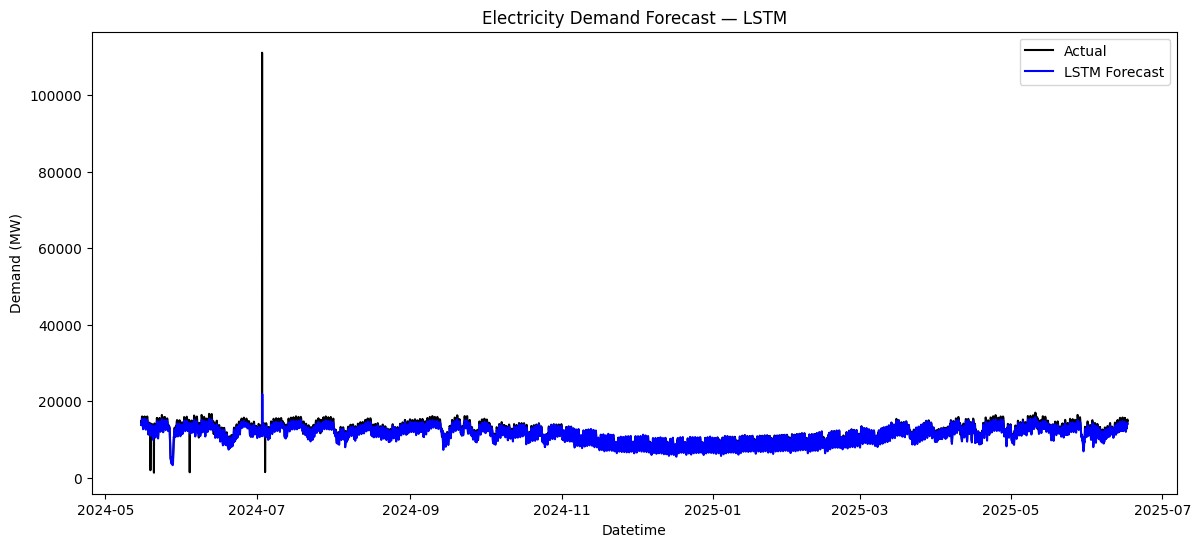

In [226]:
plt.figure(figsize=(14,6))

plt.plot(
    test_set.index[seq_length:],
    y_test_actual,
    label="Actual",
    color="black"
)

plt.plot(
    test_set.index[seq_length:],
    predictions_actual,
    label="LSTM Forecast",
    color="blue"
)

plt.legend()
plt.title("Electricity Demand Forecast — LSTM")
plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.show()

### Training Loss

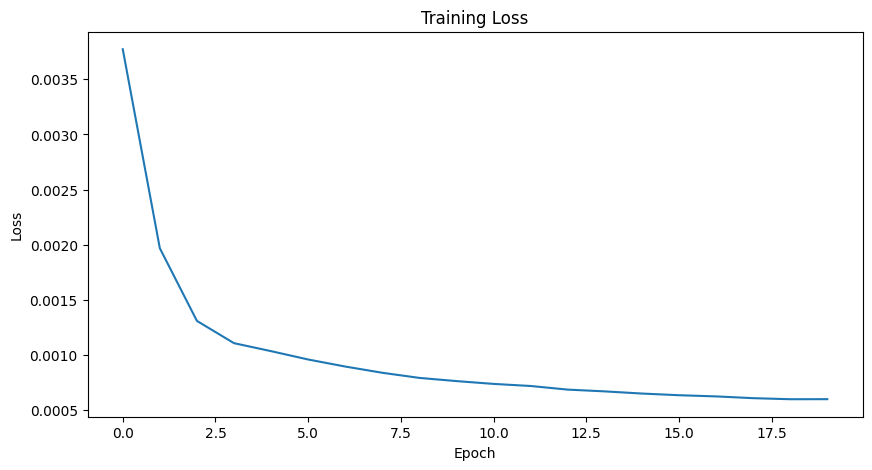

In [227]:
plt.figure(figsize=(10,5))

plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### Residual Analysis

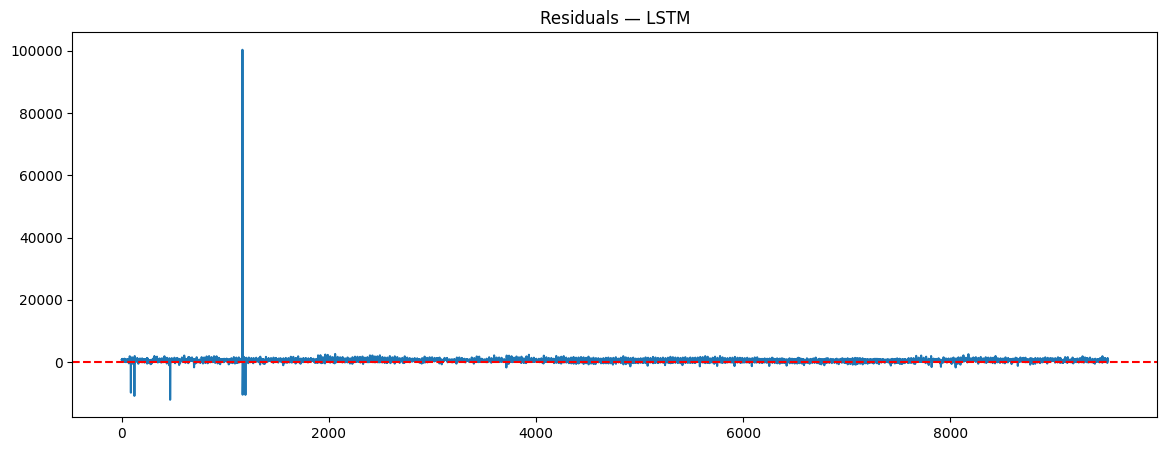

In [228]:
residuals = y_test_actual - predictions_actual

plt.figure(figsize=(14,5))
plt.plot(residuals)
plt.axhline(
    0,
    color='red',
    linestyle='--'
)

plt.title("Residuals — LSTM")
plt.show()

### Result

In [229]:
lstm_result = pd.DataFrame({
    'datetime': test_set.index[seq_length:],
    'actual': y_test_actual,
    'predicted': predictions_actual
})
lstm_result.head()

,datetime,actual,predicted
0,2024-05-15 12:00:00,14549.999765,13839.492903
1,2024-05-15 13:00:00,14750.000411,14069.241418
2,2024-05-15 14:00:00,14949.999889,14120.404673
3,2024-05-15 15:00:00,14849.999566,14035.324388
4,2024-05-15 16:00:00,14630.000490,13688.057374


# Model Performance Comparison

This project evaluates three different forecasting approaches:

- Machine Learning Model (XGBoost)
- Deep Learning Model (LSTM)
- Statistical Time-Series Model (Prophet)

The models were evaluated using:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R2 Score
- MAPE (Mean Absolute Percentage Error)

## Performance Comparison Table

| Model | Category | MAE ↓ | RMSE ↓ | R2 ↑ | MAPE ↓ |
|---|---|---|---|---|---|
| XGBoost | Machine Learning | 194.59 | 1099.41 | 0.8020 | 1.81% |
| LSTM | Deep Learning | 551.28 | 1232.60 | 0.7511 | 4.96% |
| Prophet | Statistical Model | 913.26 | 1552.84 | 0.6050 | 8.71% |

## Result Summary

Among all models, *XGBoost achieved the best overall performance* with the lowest MAE, RMSE, and MAPE, along with the highest R2 score. This indicates that the machine learning approach captured the complex patterns of electricity demand more effectively than the other models.

The *LSTM model* also performed reasonably well and demonstrated the capability of deep learning in sequential forecasting tasks. However, its performance was slightly lower compared to XGBoost, possibly due to dataset size, sequence dependency limitations, or hyperparameter tuning constraints.

The *Prophet model* showed the lowest performance among the three approaches. Although Prophet is effective for trend and seasonality analysis, it struggled to capture the complex nonlinear behavior of electricity demand in this dataset.

Overall, the experiment demonstrates that the *machine learning approach (XGBoost) outperformed both deep learning and statistical forecasting models* for this electricity demand prediction task.

## Final Conclusion

XGBoost proved to be the most reliable and accurate model for this project, making it suitable for real-world electricity demand forecasting applications. The comparative analysis also highlights the importance of evaluating multiple modeling approaches, including statistical, machine learning, and deep learning methods, before selecting the final production model.